## modeling on STN_0003

### train set <2025-08-01,  test set >2025-08-01

### output:
- columns to output for modelling: 
        - canonical_station_id, ts_hour, station_netflow, model_netflow

### for dashboarding: 
- additional column 
        ⁠- canonical_station_id, ts_hour, num_available_bikes, num_available_docks
- powerbi formula -> 10% capacity or lower to be flagged out
- powerbi timestamp -> transform to Montreal ts


In [1]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import col, explode, regexp_extract
from pyspark.sql.types import StructType, ArrayType, StringType, LongType, DoubleType, BooleanType
from pyspark.sql.functions import udf
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.regression import LinearRegression
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.regression import GeneralizedLinearRegression
from pyspark.ml.feature import VectorAssembler

import matplotlib.pyplot as plt
import pandas as pd
import requests
import json
import math
import geopandas as gpd
import os
import pyproj
import datetime
import folium

from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
import seaborn as sns

In [2]:
# read 2 functions from bixi-analytics/utils/yc__loss_func.py
import sys
sys.path.append('../utils')  # go up one level
from yc__loss_func import asymmetric_loss_col, asymmetric_loss_mean


In [ ]:
# Stop any existing SparkSession to avoid conflicts
if 'spark' in locals() and spark is not None:
    spark.stop()

spark = SparkSession.builder.appName("stn0003-modeling").getOrCreate()
print(spark.version)
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/18 15:39:49 WARN Utils: Your hostname, users-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.249.2.66 instead (on interface en0)
26/04/18 15:39:49 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/18 15:39:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


4.1.1


In [4]:
def haversine_km(lat1, lon1, lat2, lon2):
    # Radius of the Earth in km
    R = 6371.0

    # Convert degrees to radians
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    # Haversine formula
    a = math.sin(dphi / 2.0)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2.0)**2
    c = 2.0 * math.atan2(math.sqrt(a), math.sqrt(1.0 - a))

    return R * c

# Register as a Spark UDF
haversine_km_udf = udf(haversine_km, DoubleType())

Get Data from GOLD

In [5]:
gold_parquet_path = '../../data/gold/station_flow/station_id=STN_0003_new/'

# Load the parquet files into a Spark DataFrame
gold_0003_df = spark.read.parquet(gold_parquet_path)

# --- IGNORE --- not required –––––––––
# # Filter rides to include only months between April (4) and October (10) for both start and end times
# ride_df = ride_df.filter(
#     (F.month("start_time_ms") >= 4) & (F.month("start_time_ms") <= 10) &
#     (F.month("end_time_ms") >= 4) & (F.month("end_time_ms") <= 10)
# )

print(f"Loaded and filtered gold_0003_df with {gold_0003_df.count()} rows and {len(gold_0003_df.columns)} columns.")
gold_0003_df.printSchema()
gold_0003_df.show(5)

Loaded and filtered gold_0003_df with 24610 rows and 64 columns.
root
 |-- ts_hour: timestamp (nullable = true)
 |-- station_inflow: long (nullable = true)
 |-- station_outflow: long (nullable = true)
 |-- station_netflow: long (nullable = true)
 |-- radius100m_inflow_lag1: long (nullable = true)
 |-- radius100m_outflow_lag1: long (nullable = true)
 |-- radius100m_inflow_lag12: long (nullable = true)
 |-- radius100m_outflow_lag12: long (nullable = true)
 |-- radius100m_inflow_rollmean6: double (nullable = true)
 |-- radius100m_outflow_rollmean6: double (nullable = true)
 |-- radius100m_inflow_rollmean12: double (nullable = true)
 |-- radius100m_outflow_rollmean12: double (nullable = true)
 |-- radius100m_inflow_rollsum6: long (nullable = true)
 |-- radius100m_outflow_rollsum6: long (nullable = true)
 |-- radius100m_inflow_rollsum12: long (nullable = true)
 |-- radius100m_outflow_rollsum12: long (nullable = true)
 |-- radius200m_inflow_lag1: long (nullable = true)
 |-- radius200m_outflo

26/04/18 15:40:02 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------------------+--------------+---------------+---------------+----------------------+-----------------------+-----------------------+------------------------+---------------------------+----------------------------+----------------------------+-----------------------------+--------------------------+---------------------------+---------------------------+----------------------------+----------------------+-----------------------+-----------------------+------------------------+---------------------------+----------------------------+----------------------------+-----------------------------+--------------------------+---------------------------+---------------------------+----------------------------+----------------------+-----------------------+-----------------------+------------------------+---------------------------+----------------------------+----------------------------+-----------------------------+--------------------------+---------------------------+-----------------

In [6]:
# !pip install geopandas pyogrio

## Prediction Target: Inflow
## Output Model: Inflow model

feature importance

In [7]:
ALL_COLUMNS = ['ts_hour', 'station_inflow', 'station_outflow', 'station_netflow', 'radius100m_inflow_lag1', 'radius100m_outflow_lag1', 'radius100m_inflow_lag12', 'radius100m_outflow_lag12', 'radius100m_inflow_rollmean6', 'radius100m_outflow_rollmean6', 'radius100m_inflow_rollmean12', 'radius100m_outflow_rollmean12', 'radius100m_inflow_rollsum6', 'radius100m_outflow_rollsum6', 'radius100m_inflow_rollsum12', 'radius100m_outflow_rollsum12', 'radius200m_inflow_lag1', 'radius200m_outflow_lag1', 'radius200m_inflow_lag12', 'radius200m_outflow_lag12', 'radius200m_inflow_rollmean6', 'radius200m_outflow_rollmean6', 'radius200m_inflow_rollmean12', 'radius200m_outflow_rollmean12', 'radius200m_inflow_rollsum6', 'radius200m_outflow_rollsum6', 'radius200m_inflow_rollsum12', 'radius200m_outflow_rollsum12', 'radius500m_inflow_lag1', 'radius500m_outflow_lag1', 'radius500m_inflow_lag12', 'radius500m_outflow_lag12', 'radius500m_inflow_rollmean6', 'radius500m_outflow_rollmean6', 'radius500m_inflow_rollmean12', 'radius500m_outflow_rollmean12', 'radius500m_inflow_rollsum6', 'radius500m_outflow_rollsum6', 'radius500m_inflow_rollsum12', 'radius500m_outflow_rollsum12', 'temp', 'precip', 'station_inflow_lag1', 'station_outflow_lag1', 'station_inflow_lag12', 'station_outflow_lag12', 'precip_rollmean3', 'station_inflow_rollmean6', 'station_outflow_rollmean6', 'station_inflow_rollmean12', 'station_outflow_rollmean12', 'precip_rollsum3', 'station_inflow_rollsum6', 'station_outflow_rollsum6', 'station_inflow_rollsum12', 'station_outflow_rollsum12', 'temp_bin', 'dow', 'is_weekday', 'hod', 'moy', 'dow_cos', 'hod_cos', 'moy_cos']

TIME_COL = "ts_hour"
TARGET_COL = "station_inflow"   # change to station_outflow or station_netflow as needed

# features to exclude from predictors
BASE_EXCLUDE = [TIME_COL, "station_inflow", "station_outflow", "station_netflow"]

# categorical columns detected from your schema preview
CATEGORICAL_COLS = ["temp_bin"]

# boolean columns
BOOLEAN_COLS = ["is_weekday"]

# numeric columns inferred from your schema preview
NUMERIC_COLS = [c for c in ALL_COLUMNS if c not in BASE_EXCLUDE + CATEGORICAL_COLS + BOOLEAN_COLS]

print("Target:", TARGET_COL)
print("Numeric feature count:", len(NUMERIC_COLS))
print("Categorical feature count:", len(CATEGORICAL_COLS))
print("Boolean feature count:", len(BOOLEAN_COLS))

Target: station_inflow
Numeric feature count: 58
Categorical feature count: 1
Boolean feature count: 1


In [8]:
# fill numeric nulls with 0 for a stable exploratory screen
fill_map = {c: 0.0 for c in NUMERIC_COLS}
fill_map.update({c: 0 for c in BOOLEAN_COLS})

screen_df = gold_0003_df.fillna(fill_map)

# string index + one-hot encode temp_bin
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in CATEGORICAL_COLS]
encoders = [OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"]) for c in CATEGORICAL_COLS]

screen_feature_inputs = NUMERIC_COLS + BOOLEAN_COLS + [f"{c}_ohe" for c in CATEGORICAL_COLS]
assembler = VectorAssembler(inputCols=screen_feature_inputs, outputCol="features_raw", handleInvalid="keep")
scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withMean=False, withStd=True)

screen_pipe = Pipeline(stages=indexers + encoders + [assembler, scaler])
screen_model = screen_pipe.fit(screen_df)
screen_ready = screen_model.transform(screen_df).select(TIME_COL, TARGET_COL, "features_raw", "features_scaled")
print("Exploratory screening rows:", screen_ready.count())

# helper to expand feature names after OHE
def get_feature_names_from_pipeline_model(pipeline_model, numeric_cols, boolean_cols, categorical_cols):
    feature_names = list(numeric_cols) + list(boolean_cols)
    for c in categorical_cols:
        idx_model = next(s for s in pipeline_model.stages if hasattr(s, 'getOutputCol') and s.getOutputCol() == f"{c}_idx")
        labels = list(idx_model.labels) + ["__unknown__"]
        drop_last = True  # default behavior of Spark OHE
        usable = labels[:-1] if drop_last and len(labels) > 1 else labels
        feature_names.extend([f"{c}={lab}" for lab in usable])
    return feature_names

screen_feature_names = get_feature_names_from_pipeline_model(screen_model, NUMERIC_COLS, BOOLEAN_COLS, CATEGORICAL_COLS)
len(screen_feature_names), screen_feature_names[:10]

Exploratory screening rows: 24610


(68,
 ['radius100m_inflow_lag1',
  'radius100m_outflow_lag1',
  'radius100m_inflow_lag12',
  'radius100m_outflow_lag12',
  'radius100m_inflow_rollmean6',
  'radius100m_outflow_rollmean6',
  'radius100m_inflow_rollmean12',
  'radius100m_outflow_rollmean12',
  'radius100m_inflow_rollsum6',
  'radius100m_outflow_rollsum6'])

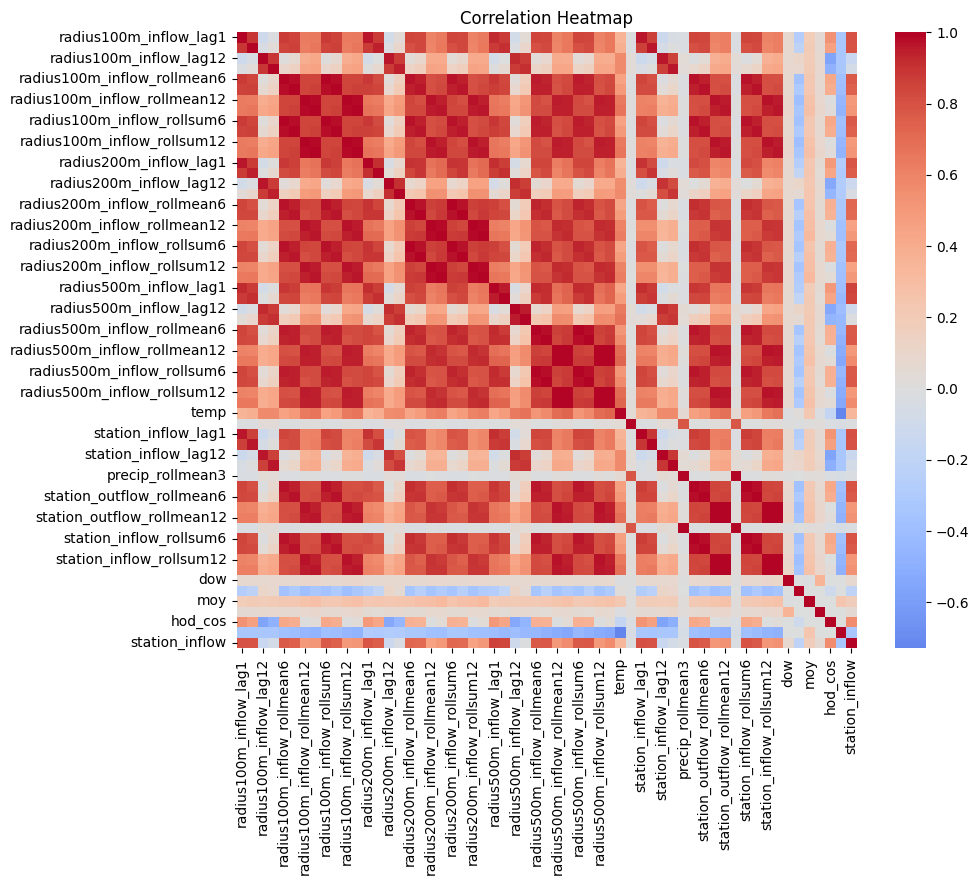

In [9]:
pdf = screen_df.select(NUMERIC_COLS + [TARGET_COL]).toPandas()
plt.figure(figsize=(10,8))
sns.heatmap(pdf.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

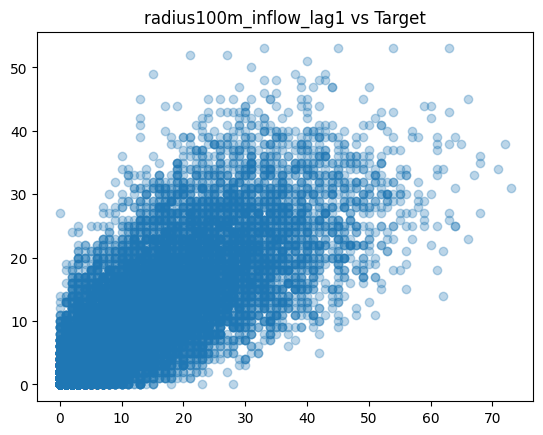

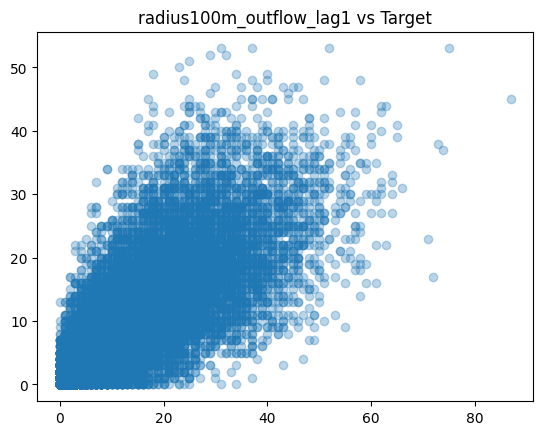

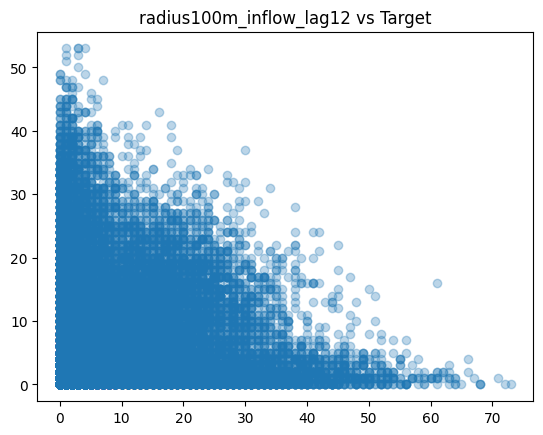

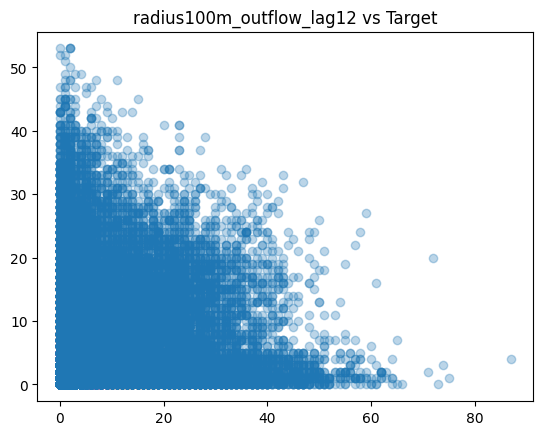

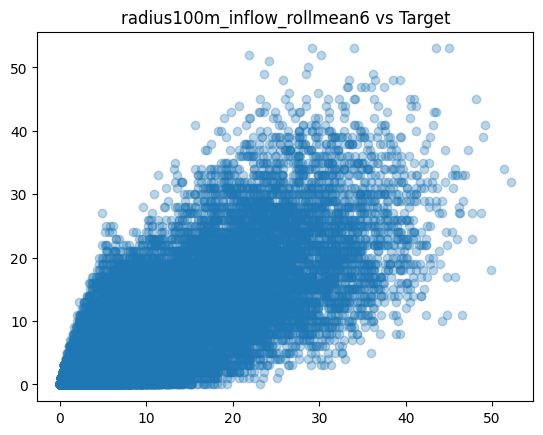

In [10]:
for col in NUMERIC_COLS[:5]:
    plt.scatter(pdf[col], pdf[TARGET_COL], alpha=0.3)
    plt.title(f"{col} vs Target")
    plt.show()

In [11]:
# Define the evaluators for each metric
evaluator_rmse = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="mae")
evaluator_r2   = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="r2")

print("Evaluators defined: evaluator_rmse, evaluator_mae, evaluator_r2")

Evaluators defined: evaluator_rmse, evaluator_mae, evaluator_r2


In [12]:
preview = gold_0003_df.limit(1).toPandas()
preview.to_csv("schema_preview.csv", index=False)

In [13]:
# Time-based Split

# define cutoff date
cutoff_date = "2025-08-01"
# split data
train_df = gold_0003_df.filter(F.col("ts_hour") < cutoff_date)
test_df  = gold_0003_df.filter(F.col("ts_hour") >= cutoff_date)

# sanity checks
print(f"Cutoff date: {cutoff_date}")
print(f"Data ready. Total rows: {gold_0003_df.count()}")
print(f"Training set: {train_df.count()} rows")
print(f"Testing set: {test_df.count()} rows")


Cutoff date: 2025-08-01
Data ready. Total rows: 24610
Training set: 20185 rows
Testing set: 4425 rows


In [14]:
# exploratory tree-based importance
rf_screen = RandomForestRegressor(
    featuresCol="features_raw",
    labelCol=TARGET_COL,
    predictionCol="prediction",
    numTrees=80,
    maxDepth=8,
    seed=42
)
rf_screen_model = rf_screen.fit(screen_ready)

rf_importance_pdf = pd.DataFrame({
    "feature": screen_feature_names,
    "importance": list(rf_screen_model.featureImportances.toArray())
}).sort_values("importance", ascending=False)

rf_importance_pdf.head(20)

26/04/18 15:40:24 WARN DAGScheduler: Broadcasting large task binary with size 1190.8 KiB
26/04/18 15:40:27 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/04/18 15:40:31 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


,feature,importance
25,radius500m_outflow_lag1,0.258609
24,radius500m_inflow_lag1,0.246509
38,station_inflow_lag1,0.085654
0,radius100m_inflow_lag1,0.053811
53,hod,0.045220
39,station_outflow_lag1,0.040087
56,hod_cos,0.039586
48,station_inflow_rollsum6,0.034581
13,radius200m_outflow_lag1,0.029060
1,radius100m_outflow_lag1,0.027985


In [15]:
# exploratory linear importance using standardized features
lr_screen = LinearRegression(
    featuresCol="features_scaled",
    labelCol=TARGET_COL,
    predictionCol="prediction",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)
lr_screen_model = lr_screen.fit(screen_ready)

lr_importance_pdf = pd.DataFrame({
    "feature": screen_feature_names,
    "coefficient": list(lr_screen_model.coefficients.toArray())
})
lr_importance_pdf["abs_coefficient"] = lr_importance_pdf["coefficient"].abs()
lr_importance_pdf = lr_importance_pdf.sort_values("abs_coefficient", ascending=False)

lr_importance_pdf.head(20)

26/04/18 15:40:37 WARN Instrumentation: [2d065816] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:40:37 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/18 15:40:38 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
26/04/18 15:40:38 WARN Instrumentation: [2d065816] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


,feature,coefficient,abs_coefficient
30,radius500m_inflow_rollmean12,-5.655598,5.655598
34,radius500m_inflow_rollsum12,-5.550299,5.550299
35,radius500m_outflow_rollsum12,5.395568,5.395568
31,radius500m_outflow_rollmean12,5.280051,5.280051
48,station_inflow_rollsum6,4.692730,4.692730
43,station_inflow_rollmean6,4.676264,4.676264
24,radius500m_inflow_lag1,4.206908,4.206908
25,radius500m_outflow_lag1,2.469243,2.469243
29,radius500m_outflow_rollmean6,-2.096524,2.096524
33,radius500m_outflow_rollsum6,-2.076604,2.076604


In [16]:
# choose candidate features from the exploratory screen
TOP_N_TREE = 25
TOP_N_LINEAR = 25

tree_top = rf_importance_pdf.head(TOP_N_TREE)["feature"].tolist()
linear_top = lr_importance_pdf.head(TOP_N_LINEAR)["feature"].tolist()

screen_top_union = sorted(set(tree_top) | set(linear_top))
print("Union of shortlisted features:", len(screen_top_union))
screen_top_union[:20]

Union of shortlisted features: 34


['dow',
 'hod',
 'hod_cos',
 'radius100m_inflow_lag1',
 'radius100m_inflow_lag12',
 'radius100m_inflow_rollmean6',
 'radius100m_inflow_rollsum6',
 'radius100m_outflow_lag1',
 'radius100m_outflow_rollmean6',
 'radius100m_outflow_rollsum6',
 'radius200m_inflow_lag1',
 'radius200m_outflow_lag1',
 'radius500m_inflow_lag1',
 'radius500m_inflow_lag12',
 'radius500m_inflow_rollmean12',
 'radius500m_inflow_rollsum12',
 'radius500m_inflow_rollsum6',
 'radius500m_outflow_lag1',
 'radius500m_outflow_lag12',
 'radius500m_outflow_rollmean12']

In [17]:
time_bounds = gold_0003_df.select(
    F.min(TIME_COL).alias("min_ts"),
    F.max(TIME_COL).alias("max_ts")
).first()

min_ts = time_bounds["min_ts"]
max_ts = time_bounds["max_ts"]

timeline = gold_0003_df.select(TIME_COL).distinct().orderBy(TIME_COL)
n_time_points = timeline.count()
split_idx = int(math.floor(n_time_points * 0.8))

split_ts = timeline.collect()[split_idx - 1][TIME_COL] if split_idx > 0 else min_ts

print("Min timestamp:", min_ts)
print("Max timestamp:", max_ts)
print("Distinct time points:", n_time_points)
print("80/20 split timestamp:", split_ts)

train_full_df = gold_0003_df.filter(F.col(TIME_COL) <= F.lit(split_ts))
test_df = gold_0003_df.filter(F.col(TIME_COL) > F.lit(split_ts))

print("Train_full rows:", train_full_df.count())
print("Test rows:", test_df.count())

Min timestamp: 2023-04-12 23:00:00
Max timestamp: 2026-02-01 08:00:00
Distinct time points: 24610
80/20 split timestamp: 2025-07-11 06:00:00
Train_full rows: 19688
Test rows: 4922


##### 8. Create a validation window inside the training period

For hyperparameter tuning, avoid peeking at the test set.  
This notebook splits the 80% training window again into:
- earlier **train**
- later **validation**

The final 20% remains untouched for final evaluation.

In [18]:
train_timeline = train_full_df.select(TIME_COL).distinct().orderBy(TIME_COL)
n_train_time_points = train_timeline.count()
val_start_idx = int(math.floor(n_train_time_points * 0.8))
val_start_ts = train_timeline.collect()[val_start_idx - 1][TIME_COL] if val_start_idx > 0 else split_ts

train_df = train_full_df.filter(F.col(TIME_COL) <= F.lit(val_start_ts))
val_df = train_full_df.filter(F.col(TIME_COL) > F.lit(val_start_ts))

print("Train rows:", train_df.count())
print("Validation rows:", val_df.count())
print("Validation start timestamp:", val_start_ts)

Train rows: 15750
Validation rows: 3938
Validation start timestamp: 2025-01-28 04:00:00


use all engineered features

In [19]:
## set USE_SCREENED_FEATURES to True if want to use reduced feature set
USE_SCREENED_FEATURES = False

if USE_SCREENED_FEATURES:
    # screen_top_union contains expanded names after OHE, so for actual assembly we keep all original columns
    # and later inspect importance again on the training-only data
    print("Using original columns but screened results only as guidance.")

MODEL_NUMERIC_COLS = NUMERIC_COLS
MODEL_BOOLEAN_COLS = BOOLEAN_COLS
MODEL_CATEGORICAL_COLS = CATEGORICAL_COLS

fill_map = {c: 0.0 for c in MODEL_NUMERIC_COLS}
fill_map.update({c: 0 for c in MODEL_BOOLEAN_COLS})

train_df = train_df.fillna(fill_map)
val_df = val_df.fillna(fill_map)
test_df = test_df.fillna(fill_map)

indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in MODEL_CATEGORICAL_COLS]
encoders = [OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"]) for c in MODEL_CATEGORICAL_COLS]

feature_inputs = MODEL_NUMERIC_COLS + MODEL_BOOLEAN_COLS + [f"{c}_ohe" for c in MODEL_CATEGORICAL_COLS]
assembler = VectorAssembler(inputCols=feature_inputs, outputCol="features_raw", handleInvalid="keep")
scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withMean=False, withStd=True)

prep_pipe = Pipeline(stages=indexers + encoders + [assembler, scaler])
prep_model = prep_pipe.fit(train_df)

train_ready = prep_model.transform(train_df)
val_ready = prep_model.transform(val_df)
test_ready = prep_model.transform(test_df)

model_feature_names = get_feature_names_from_pipeline_model(prep_model, MODEL_NUMERIC_COLS, MODEL_BOOLEAN_COLS, MODEL_CATEGORICAL_COLS)
print("Prepared feature count:", len(model_feature_names))

Prepared feature count: 68


In [20]:
evaluator_specs = ["rmse", "mae", "r2"]

def evaluate_predictions(pred_df, label_col=TARGET_COL):
    out = {}
    for metric in evaluator_specs:
        ev = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName=metric)
        out[metric] = ev.evaluate(pred_df)
    return out

def fit_and_evaluate(model_name, estimator, train_data, eval_data, features_col):
    fitted = estimator.fit(train_data)
    pred = fitted.transform(eval_data)
    metrics = evaluate_predictions(pred, TARGET_COL)
    return {
        "model_name": model_name,
        "features_col": features_col,
        "fitted_model": fitted,
        "predictions": pred,
        "rmse": metrics["rmse"],
        "mae": metrics["mae"],
        "r2": metrics["r2"],
    }

def extract_tree_importance(model, feature_names):
    if hasattr(model, "featureImportances"):
        return pd.DataFrame({
            "feature": feature_names,
            "importance": list(model.featureImportances.toArray())
        }).sort_values("importance", ascending=False)
    return None

def extract_linear_importance(model, feature_names):
    if hasattr(model, "coefficients"):
        pdf = pd.DataFrame({
            "feature": feature_names,
            "coefficient": list(model.coefficients.toArray())
        })
        pdf["abs_coefficient"] = pdf["coefficient"].abs()
        return pdf.sort_values("abs_coefficient", ascending=False)
    return None

#### 11. First-round baseline training

Design choice:
- tree models use `features_raw`
- linear models use `features_scaled`
- Poisson GLR assumes a non-negative target, so use it mainly for `station_inflow` or `station_outflow`

Model Training - To Try All types of Time Series Regression supported by Spark

In [21]:
baseline_models = {
    "GBTRegressor": GBTRegressor(
        featuresCol="features_raw",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxIter=100,
        maxDepth=5,
        maxBins=32,
        stepSize=0.1,
        subsamplingRate=1.0,
        seed=42
    ),
    "RandomForestRegressor": RandomForestRegressor(
        featuresCol="features_raw",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        numTrees=100,
        maxDepth=8,
        maxBins=32,
        seed=42
    ),
    "DecisionTreeRegressor": DecisionTreeRegressor(
        featuresCol="features_raw",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxDepth=8,
        maxBins=32,
        seed=42
    ),
    "LinearRegression": LinearRegression(
        featuresCol="features_scaled",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxIter=100,
        regParam=0.1,
        elasticNetParam=0.0
    ),
    "GeneralizedLinearRegression": GeneralizedLinearRegression(
        featuresCol="features_scaled",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        family="poisson",
        link="log",
        maxIter=50,
        regParam=0.0
    )
}

In [22]:
baseline_results = []

for model_name, estimator in baseline_models.items():
    if model_name == "GeneralizedLinearRegression" and TARGET_COL == "station_netflow":
        print(f"Skipping {model_name} because Poisson GLR is not suitable for negative netflow targets.")
        continue

    features_col = estimator.getFeaturesCol()
    result = fit_and_evaluate(model_name, estimator, train_ready, val_ready, features_col)
    baseline_results.append(result)
    print(model_name, {k: result[k] for k in ['rmse', 'mae', 'r2']})

baseline_metrics_pdf = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["fitted_model", "predictions"]}
    for r in baseline_results
]).sort_values("rmse")

baseline_metrics_pdf

GBTRegressor {'rmse': 3.0666498247612464, 'mae': 2.0495041824645264, 'r2': 0.8579726461625488}


26/04/18 15:41:40 WARN DAGScheduler: Broadcasting large task binary with size 1432.2 KiB
26/04/18 15:41:43 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/04/18 15:41:46 WARN DAGScheduler: Broadcasting large task binary with size 4.9 MiB
26/04/18 15:41:50 WARN DAGScheduler: Broadcasting large task binary with size 1143.4 KiB


RandomForestRegressor {'rmse': 3.114718248215699, 'mae': 2.1435864087403216, 'r2': 0.8534853151832085}


DecisionTreeRegressor {'rmse': 3.4129721285294092, 'mae': 2.3010230477825657, 'r2': 0.8240824759128493}
LinearRegression {'rmse': 3.4388491626787143, 'mae': 2.4457249666310634, 'r2': 0.8214047621747088}


26/04/18 15:41:59 WARN Instrumentation: [aab0a229] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:42:00 WARN Instrumentation: [aab0a229] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:42:00 WARN Instrumentation: [aab0a229] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:42:00 WARN Instrumentation: [aab0a229] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:42:00 WARN Instrumentation: [aab0a229] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:42:01 WARN Instrumentation: [aab0a229] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:42:01 WARN Instrumentation: [aab0a229] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:42:01 WARN Instrumentation: [aab0a229] Cholesky solv

GeneralizedLinearRegression {'rmse': 4.031530124399136, 'mae': 2.7936283642580224, 'r2': 0.7545384687204917}


,model_name,features_col,rmse,mae,r2
0,GBTRegressor,features_raw,3.066650,2.049504,0.857973
1,RandomForestRegressor,features_raw,3.114718,2.143586,0.853485
2,DecisionTreeRegressor,features_raw,3.412972,2.301023,0.824082
3,LinearRegression,features_scaled,3.438849,2.445725,0.821405
4,GeneralizedLinearRegression,features_scaled,4.031530,2.793628,0.754538


#### 12. Training-only feature importance after the baseline round


In [23]:
importance_tables = {}

for r in baseline_results:
    name = r["model_name"]
    model = r["fitted_model"]
    if name in {"GBTRegressor", "RandomForestRegressor", "DecisionTreeRegressor"}:
        importance_tables[name] = extract_tree_importance(model, model_feature_names)
    elif name in {"LinearRegression", "GeneralizedLinearRegression"}:
        importance_tables[name] = extract_linear_importance(model, model_feature_names)

list(importance_tables.keys())

['GBTRegressor',
 'RandomForestRegressor',
 'DecisionTreeRegressor',
 'LinearRegression',
 'GeneralizedLinearRegression']

In [24]:
"""inspect top 3 features from all regresssors' importance table"""

print(importance_tables['GBTRegressor'].head(3))
print(importance_tables['RandomForestRegressor'].head(3))
print(importance_tables['DecisionTreeRegressor'].head(3))
print(importance_tables['LinearRegression'].head(3))
print(importance_tables['GeneralizedLinearRegression'].head(3))

                     feature  importance
24    radius500m_inflow_lag1    0.320503
43  station_inflow_rollmean6    0.091621
53                       hod    0.071545
                    feature  importance
24   radius500m_inflow_lag1    0.273844
25  radius500m_outflow_lag1    0.213310
38      station_inflow_lag1    0.071177
                   feature  importance
24  radius500m_inflow_lag1    0.736235
39    station_outflow_lag1    0.058085
53                     hod    0.044497
                     feature  coefficient  abs_coefficient
24    radius500m_inflow_lag1     3.323945         3.323945
48   station_inflow_rollsum6     2.778028         2.778028
43  station_inflow_rollmean6     2.774281         2.774281
                     feature  coefficient  abs_coefficient
56                   hod_cos     0.448598         0.448598
48   station_inflow_rollsum6     0.399612         0.399612
43  station_inflow_rollmean6     0.394800         0.394800


#### 13. Manual time-aware hyperparameter tuning

Tunes using:
- `train_df` for fitting
- `val_df` for model selection

Which respects chronological order.

In [25]:
param_grids = {
    "GBTRegressor": [
        {"maxIter": 50, "maxDepth": 4, "stepSize": 0.05, "maxBins": 32},
        {"maxIter": 100, "maxDepth": 5, "stepSize": 0.05, "maxBins": 32},
        {"maxIter": 100, "maxDepth": 6, "stepSize": 0.1, "maxBins": 32},
    ],
    "RandomForestRegressor": [
        {"numTrees": 80, "maxDepth": 6, "maxBins": 32},
        {"numTrees": 120, "maxDepth": 8, "maxBins": 32},
        {"numTrees": 150, "maxDepth": 10, "maxBins": 64},
    ],
    "DecisionTreeRegressor": [
        {"maxDepth": 5, "maxBins": 32},
        {"maxDepth": 8, "maxBins": 32},
        {"maxDepth": 10, "maxBins": 64},
    ],
    "LinearRegression": [
        {"maxIter": 100, "regParam": 0.0, "elasticNetParam": 0.0},
        {"maxIter": 100, "regParam": 0.1, "elasticNetParam": 0.0},
        {"maxIter": 100, "regParam": 0.1, "elasticNetParam": 0.5},
        {"maxIter": 150, "regParam": 0.2, "elasticNetParam": 1.0},
    ],
    "GeneralizedLinearRegression": [
        {"maxIter": 50, "regParam": 0.0},
        {"maxIter": 100, "regParam": 0.0},
        {"maxIter": 100, "regParam": 0.1},
    ],
}


def build_estimator(model_name, params):
    if model_name == "GBTRegressor":
        return GBTRegressor(
            featuresCol="features_raw", labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, subsamplingRate=1.0, **params
        )
    if model_name == "RandomForestRegressor":
        return RandomForestRegressor(
            featuresCol="features_raw", labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, **params
        )
    if model_name == "DecisionTreeRegressor":
        return DecisionTreeRegressor(
            featuresCol="features_raw", labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, **params
        )
    if model_name == "LinearRegression":
        return LinearRegression(
            featuresCol="features_scaled", labelCol=TARGET_COL, predictionCol="prediction",
            **params
        )
    if model_name == "GeneralizedLinearRegression":
        return GeneralizedLinearRegression(
            featuresCol="features_scaled", labelCol=TARGET_COL, predictionCol="prediction",
            family="poisson", link="log", **params
        )
    raise ValueError("Unknown model")

In [26]:
tuning_rows = []

for model_name, grid in param_grids.items():
    if model_name == "GeneralizedLinearRegression" and TARGET_COL == "station_netflow":
        continue

    print(f"\nTuning {model_name}")
    for params in grid:
        est = build_estimator(model_name, params)
        fitted = est.fit(train_ready)
        pred = fitted.transform(val_ready)
        metrics = evaluate_predictions(pred, TARGET_COL)

        row = {
            "model_name": model_name,
            "params_json": json.dumps(params, sort_keys=True),
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
        }
        tuning_rows.append(row)
        print(row)

tuning_pdf = pd.DataFrame(tuning_rows).sort_values(["model_name", "rmse"])
tuning_pdf


Tuning GBTRegressor
{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 4, "maxIter": 50, "stepSize": 0.05}', 'rmse': 3.2818937321999724, 'mae': 2.24342097634429, 'r2': 0.8373355498198138}
{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 5, "maxIter": 100, "stepSize": 0.05}', 'rmse': 3.075548043725014, 'mae': 2.0612652607580744, 'r2': 0.8571472346688376}


26/04/18 15:44:00 WARN DAGScheduler: Broadcasting large task binary with size 1000.8 KiB
26/04/18 15:44:01 WARN DAGScheduler: Broadcasting large task binary with size 1001.3 KiB
26/04/18 15:44:01 WARN DAGScheduler: Broadcasting large task binary with size 1002.3 KiB
26/04/18 15:44:01 WARN DAGScheduler: Broadcasting large task binary with size 1003.1 KiB
26/04/18 15:44:01 WARN DAGScheduler: Broadcasting large task binary with size 1005.4 KiB
26/04/18 15:44:01 WARN DAGScheduler: Broadcasting large task binary with size 1010.1 KiB
26/04/18 15:44:01 WARN DAGScheduler: Broadcasting large task binary with size 1013.0 KiB
26/04/18 15:44:01 WARN DAGScheduler: Broadcasting large task binary with size 1013.5 KiB
26/04/18 15:44:01 WARN DAGScheduler: Broadcasting large task binary with size 1014.5 KiB
26/04/18 15:44:01 WARN DAGScheduler: Broadcasting large task binary with size 1015.2 KiB
26/04/18 15:44:01 WARN DAGScheduler: Broadcasting large task binary with size 1017.6 KiB
26/04/18 15:44:01 WAR

{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 6, "maxIter": 100, "stepSize": 0.1}', 'rmse': 3.143981756611936, 'mae': 2.0752956228520616, 'r2': 0.8507193026206756}

Tuning RandomForestRegressor


26/04/18 15:44:28 WARN DAGScheduler: Broadcasting large task binary with size 1193.5 KiB


{'model_name': 'RandomForestRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 6, "numTrees": 80}', 'rmse': 3.2740045187237716, 'mae': 2.3049312473480765, 'r2': 0.8381166550271879}


...

{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 50, "regParam": 0.0}', 'rmse': 4.031530124399136, 'mae': 2.7936283642580224, 'r2': 0.7545384687204917}


26/04/18 15:46:49 WARN Instrumentation: [6ec5b70c] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:46:50 WARN Instrumentation: [6ec5b70c] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:46:50 WARN Instrumentation: [6ec5b70c] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:46:51 WARN Instrumentation: [6ec5b70c] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:46:51 WARN Instrumentation: [6ec5b70c] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:46:51 WARN Instrumentation: [6ec5b70c] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:46:51 WARN Instrumentation: [6ec5b70c] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:46:51 WARN Instrumentation: [6ec5b70c] Cholesky solv

{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 100, "regParam": 0.0}', 'rmse': 4.032406223648584, 'mae': 2.7932093330461094, 'r2': 0.7544317737322382}


{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 100, "regParam": 0.1}', 'rmse': 4.227604981923661, 'mae': 2.923874883886672, 'r2': 0.7300816424097307}


,model_name,params_json,rmse,mae,r2
7,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",3.412972,2.301023,0.824082
8,DecisionTreeRegressor,"{""maxBins"": 64, ""maxDepth"": 10}",3.652074,2.352686,0.798571
6,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 5}",3.714738,2.623294,0.791599
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",3.075548,2.061265,0.857147
2,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 6, ""maxIter"": 100,...",3.143982,2.075296,0.850719
0,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 4, ""maxIter"": 50, ...",3.281894,2.243421,0.837336
13,GeneralizedLinearRegression,"{""maxIter"": 50, ""regParam"": 0.0}",4.031530,2.793628,0.754538
14,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.0}",4.032406,2.793209,0.754432
15,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.1}",4.227605,2.923875,0.730082
10,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",3.438849,2.445725,0.821405


In [27]:
best_params_pdf = tuning_pdf.sort_values("rmse").groupby("model_name", as_index=False).first()
best_params_pdf

,model_name,params_json,rmse,mae,r2
0,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",3.412972,2.301023,0.824082
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",3.075548,2.061265,0.857147
2,GeneralizedLinearRegression,"{""maxIter"": 50, ""regParam"": 0.0}",4.031530,2.793628,0.754538
3,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",3.438849,2.445725,0.821405
4,RandomForestRegressor,"{""maxBins"": 64, ""maxDepth"": 10, ""numTrees"": 150}",3.021519,2.047672,0.862122


#### 14. Retrain with best parameters on the full 80% training window, then evaluate on the untouched 20% test set

In [28]:
train_full_ready = prep_model.transform(train_full_df.fillna(fill_map))
test_ready = prep_model.transform(test_df.fillna(fill_map))

final_results = []

for _, row in best_params_pdf.iterrows():
    model_name = row["model_name"]
    params = json.loads(row["params_json"])
    final_est = build_estimator(model_name, params)
    final_model = final_est.fit(train_full_ready)
    final_pred = final_model.transform(test_ready)
    final_metrics = evaluate_predictions(final_pred, TARGET_COL)

    final_results.append({
        "model_name": model_name,
        "params_json": json.dumps(params, sort_keys=True),
        "rmse": final_metrics["rmse"],
        "mae": final_metrics["mae"],
        "r2": final_metrics["r2"],
        "fitted_model": final_model,
        "predictions": final_pred,
    })

final_metrics_pdf = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["fitted_model", "predictions"]}
    for r in final_results
]).sort_values("rmse")

final_metrics_pdf

26/04/18 15:48:34 WARN Instrumentation: [5deabdb6] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:48:34 WARN Instrumentation: [5deabdb6] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:48:34 WARN Instrumentation: [5deabdb6] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:48:35 WARN Instrumentation: [5deabdb6] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:48:35 WARN Instrumentation: [5deabdb6] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:48:35 WARN Instrumentation: [5deabdb6] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:48:35 WARN Instrumentation: [5deabdb6] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:48:36 WARN Instrumentation: [5deabdb6] Cholesky solv

,model_name,params_json,rmse,mae,r2
4,RandomForestRegressor,"{""maxBins"": 64, ""maxDepth"": 10, ""numTrees"": 150}",3.287420,2.240085,0.870082
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",3.387819,2.295617,0.862025
0,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",3.730455,2.542168,0.832705
3,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",3.817404,2.696150,0.824816
2,GeneralizedLinearRegression,"{""maxIter"": 50, ""regParam"": 0.0}",4.644276,3.192398,0.740705


In [29]:
"""getting the feature importance from the final models"""
final_importance_tables = {}

for r in final_results:
    name = r["model_name"]
    model = r["fitted_model"]
    if name in {"GBTRegressor", "RandomForestRegressor", "DecisionTreeRegressor"}:
        final_importance_tables[name] = extract_tree_importance(model, model_feature_names)
    elif name in {"LinearRegression", "GeneralizedLinearRegression"}:
        final_importance_tables[name] = extract_linear_importance(model, model_feature_names)

for name, pdf in final_importance_tables.items():
    print("\n", name)
    display(pdf.head(15))


 DecisionTreeRegressor


,feature,importance
24,radius500m_inflow_lag1,0.733277
25,radius500m_outflow_lag1,0.076500
53,hod,0.043693
43,station_inflow_rollmean6,0.040917
56,hod_cos,0.031152
39,station_outflow_lag1,0.019391
45,station_inflow_rollmean12,0.016571
30,radius500m_inflow_rollmean12,0.010999
52,dow,0.003771
55,dow_cos,0.003635



 GBTRegressor


,feature,importance
24,radius500m_inflow_lag1,0.272377
43,station_inflow_rollmean6,0.103956
53,hod,0.094782
25,radius500m_outflow_lag1,0.061096
56,hod_cos,0.042276
39,station_outflow_lag1,0.036996
52,dow,0.036572
55,dow_cos,0.031141
45,station_inflow_rollmean12,0.029059
30,radius500m_inflow_rollmean12,0.023162



 GeneralizedLinearRegression


,feature,coefficient,abs_coefficient
56,hod_cos,0.464920,0.464920
48,station_inflow_rollsum6,0.386332,0.386332
43,station_inflow_rollmean6,0.382872,0.382872
25,radius500m_outflow_lag1,0.331750,0.331750
35,radius500m_outflow_rollsum12,0.258846,0.258846
26,radius500m_inflow_lag12,0.257202,0.257202
31,radius500m_outflow_rollmean12,0.244644,0.244644
28,radius500m_inflow_rollmean6,-0.229481,0.229481
30,radius500m_inflow_rollmean12,-0.228635,0.228635
32,radius500m_inflow_rollsum6,-0.226254,0.226254



 LinearRegression


,feature,coefficient,abs_coefficient
24,radius500m_inflow_lag1,3.368235,3.368235
48,station_inflow_rollsum6,2.786341,2.786341
43,station_inflow_rollmean6,2.783879,2.783879
25,radius500m_outflow_lag1,2.512290,2.512290
30,radius500m_inflow_rollmean12,-2.027825,2.027825
34,radius500m_inflow_rollsum12,-2.012197,2.012197
35,radius500m_outflow_rollsum12,1.401093,1.401093
31,radius500m_outflow_rollmean12,1.384074,1.384074
27,radius500m_outflow_lag12,-1.350139,1.350139
26,radius500m_inflow_lag12,1.343823,1.343823



 RandomForestRegressor


,feature,importance
24,radius500m_inflow_lag1,0.261734
25,radius500m_outflow_lag1,0.209963
38,station_inflow_lag1,0.080215
0,radius100m_inflow_lag1,0.052696
39,station_outflow_lag1,0.045782
53,hod,0.042640
1,radius100m_outflow_lag1,0.040108
56,hod_cos,0.036960
48,station_inflow_rollsum6,0.034172
43,station_inflow_rollmean6,0.028775


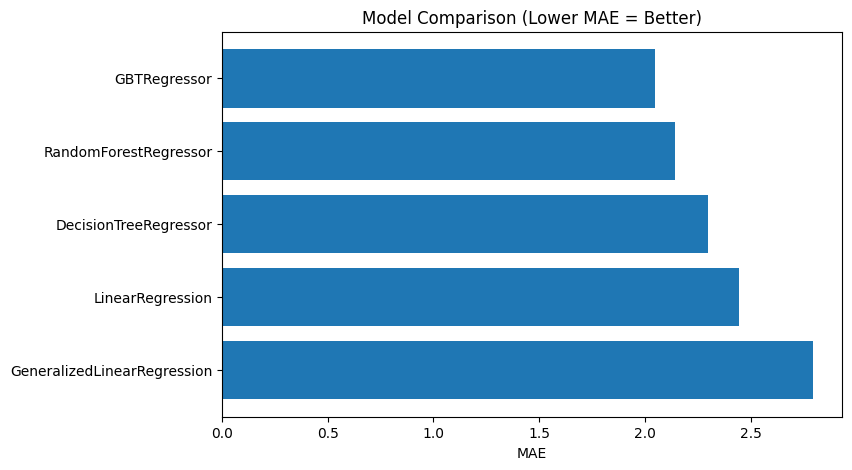

In [30]:
baseline_pdf = baseline_metrics_pdf.sort_values("mae")

plt.figure(figsize=(8,5))
plt.barh(baseline_pdf["model_name"], baseline_pdf["mae"])
plt.xlabel("MAE")
plt.title("Model Comparison (Lower MAE = Better)")
plt.gca().invert_yaxis()
plt.show()

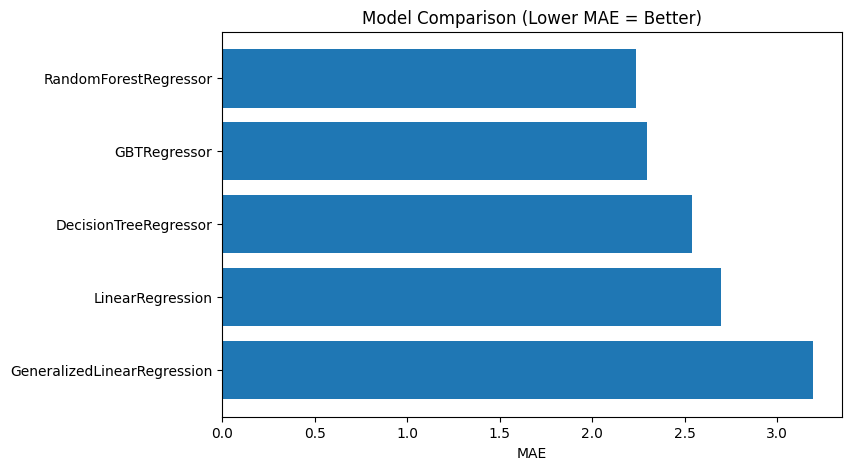

In [31]:
final_pdf = final_metrics_pdf.sort_values("mae")

plt.figure(figsize=(8,5))
plt.barh(final_pdf["model_name"], final_pdf["mae"])
plt.xlabel("MAE")
plt.title("Model Comparison (Lower MAE = Better)")
plt.gca().invert_yaxis()
plt.show()

##### 15. plot 

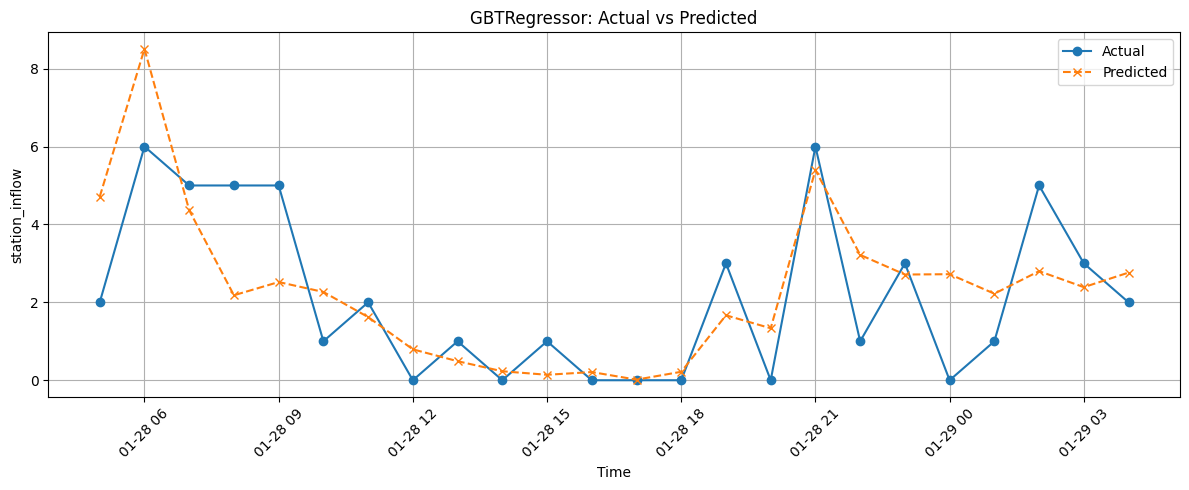

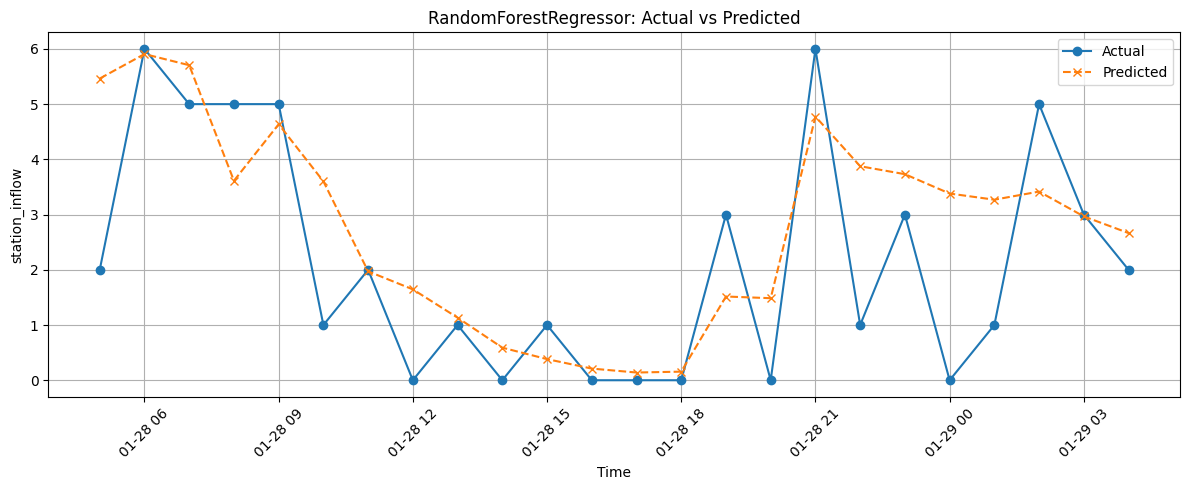

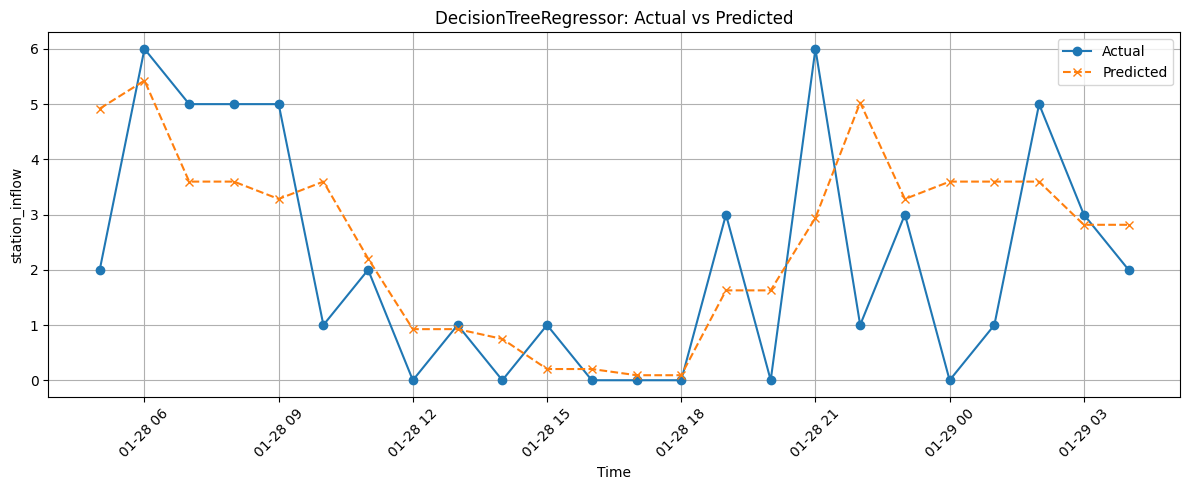

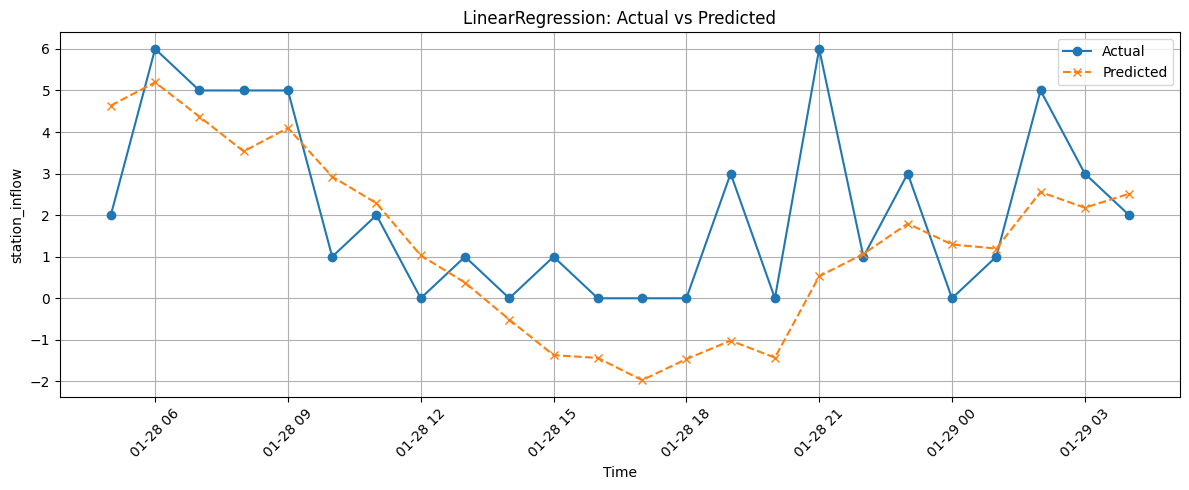

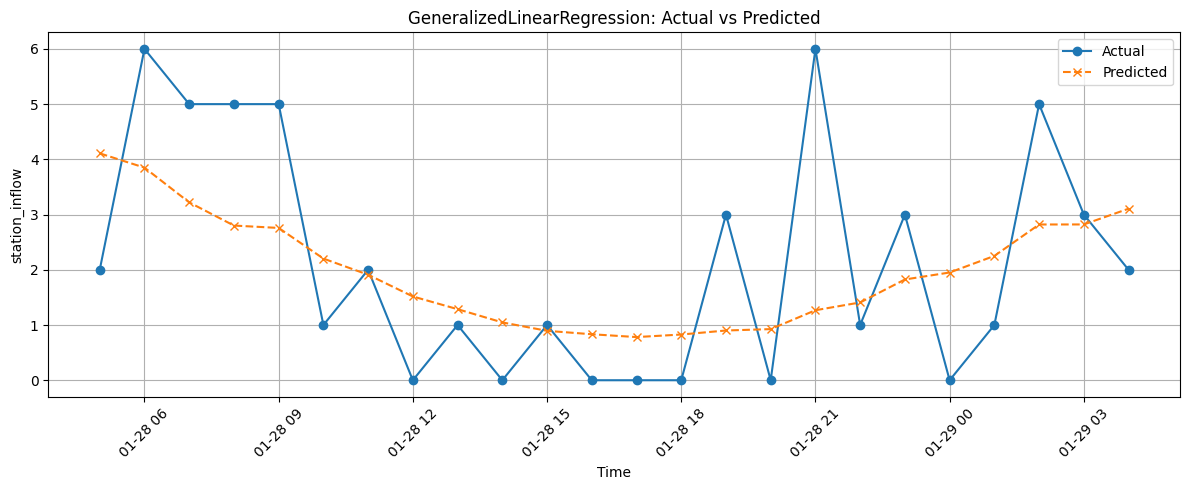

In [32]:
### plot baseline results 
for result in baseline_results:
    model_name = result["model_name"]
    pred_df = result["predictions"]

    plot_pdf = (
        pred_df
        .select("ts_hour", TARGET_COL, "prediction")
        .orderBy("ts_hour")
        .limit(24)
        .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(plot_pdf["ts_hour"], plot_pdf[TARGET_COL], label="Actual", marker="o")
    plt.plot(plot_pdf["ts_hour"], plot_pdf["prediction"], label="Predicted", linestyle="--", marker="x")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

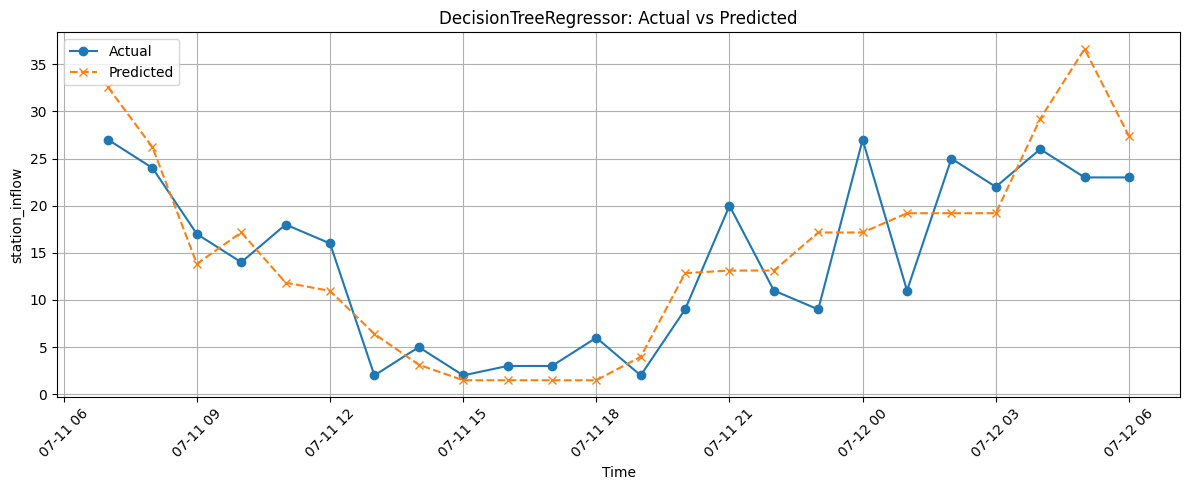

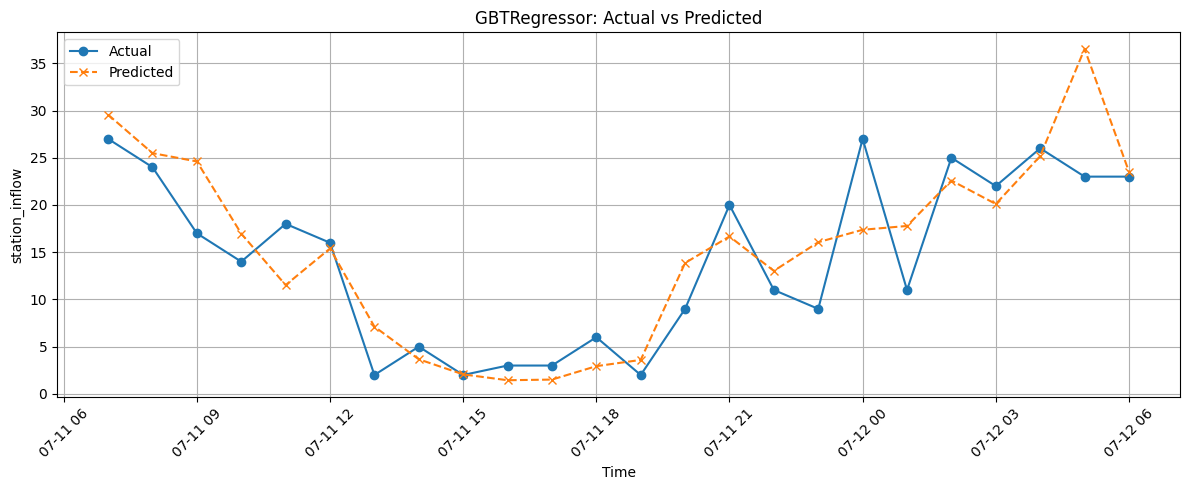

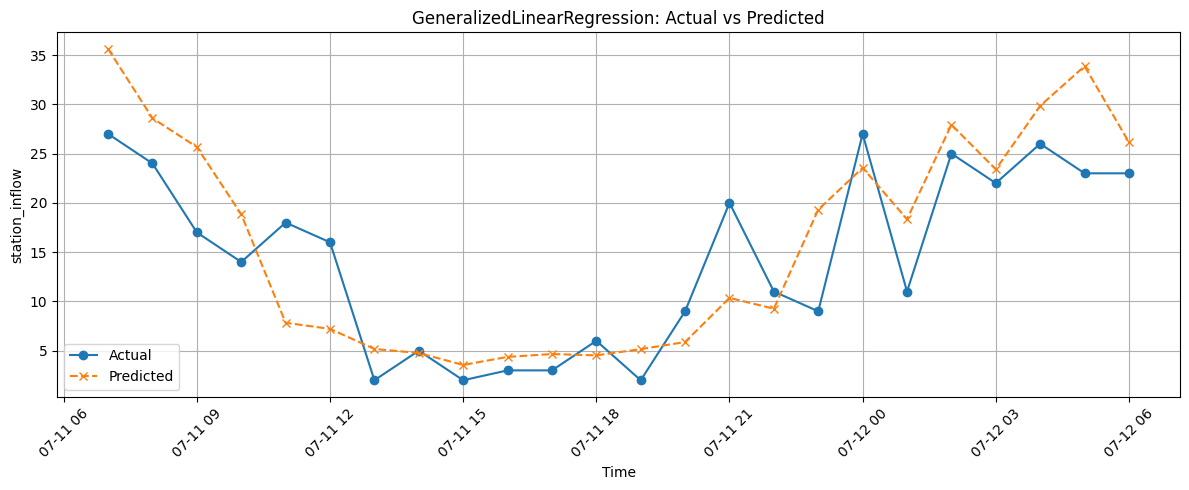

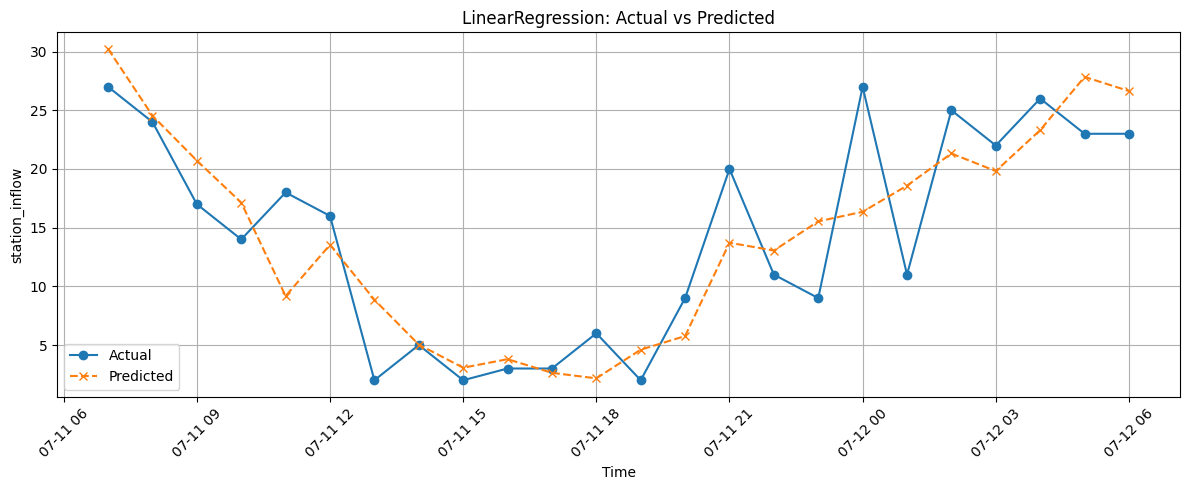

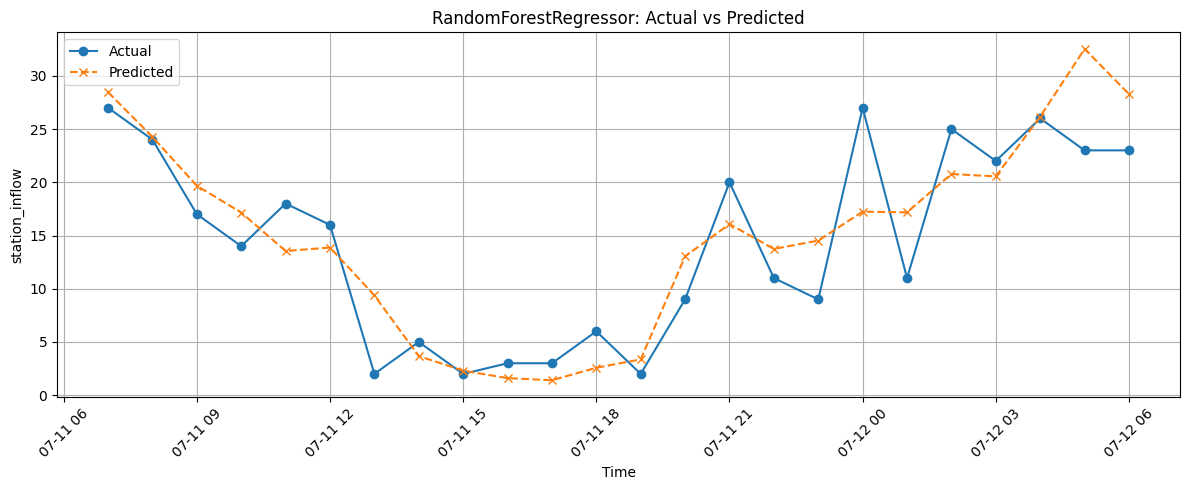

In [33]:
### plot final results 
for result in final_results:
    model_name = result["model_name"]
    pred_df = result["predictions"]

    plot_pdf = (
        pred_df
        .select("ts_hour", TARGET_COL, "prediction")
        .orderBy("ts_hour")
        .limit(24)
        .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(plot_pdf["ts_hour"], plot_pdf[TARGET_COL], label="Actual", marker="o")
    plt.plot(plot_pdf["ts_hour"], plot_pdf["prediction"], label="Predicted", linestyle="--", marker="x")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Saving the best trained INFLOW model

In [34]:
best_inflowModeling_result = min(final_results, key=lambda x: x["mae"])

best_inflow_model_name = best_inflowModeling_result["model_name"]
best_inflow_model = best_inflowModeling_result["fitted_model"]

print("Best model:", best_inflow_model_name)
print("MAE:", best_inflowModeling_result["mae"])
print("RMSE:", best_inflowModeling_result["rmse"])
print("R2:", best_inflowModeling_result["r2"])

Best model: RandomForestRegressor
MAE: 2.240084821348612
RMSE: 3.287420053103063
R2: 0.8700819927526124


In [35]:
save_path = f"outputModels/best_inflow_model_{best_inflow_model_name}"
best_inflow_model.write().overwrite().save(save_path)
print(f"Model saved to: {save_path}")

26/04/18 15:50:46 WARN TaskSetManager: Stage 5323 contains a task of very large size (6100 KiB). The maximum recommended task size is 1000 KiB.


Model saved to: outputModels/best_inflow_model_RandomForestRegressor


## Prediction Target: Outflow
## Output Model: Outflow model

feature importance

In [36]:
ALL_COLUMNS = ['ts_hour', 'station_inflow', 'station_outflow', 'station_netflow', 'radius100m_inflow_lag1', 'radius100m_outflow_lag1', 'radius100m_inflow_lag12', 'radius100m_outflow_lag12', 'radius100m_inflow_rollmean6', 'radius100m_outflow_rollmean6', 'radius100m_inflow_rollmean12', 'radius100m_outflow_rollmean12', 'radius100m_inflow_rollsum6', 'radius100m_outflow_rollsum6', 'radius100m_inflow_rollsum12', 'radius100m_outflow_rollsum12', 'radius200m_inflow_lag1', 'radius200m_outflow_lag1', 'radius200m_inflow_lag12', 'radius200m_outflow_lag12', 'radius200m_inflow_rollmean6', 'radius200m_outflow_rollmean6', 'radius200m_inflow_rollmean12', 'radius200m_outflow_rollmean12', 'radius200m_inflow_rollsum6', 'radius200m_outflow_rollsum6', 'radius200m_inflow_rollsum12', 'radius200m_outflow_rollsum12', 'radius500m_inflow_lag1', 'radius500m_outflow_lag1', 'radius500m_inflow_lag12', 'radius500m_outflow_lag12', 'radius500m_inflow_rollmean6', 'radius500m_outflow_rollmean6', 'radius500m_inflow_rollmean12', 'radius500m_outflow_rollmean12', 'radius500m_inflow_rollsum6', 'radius500m_outflow_rollsum6', 'radius500m_inflow_rollsum12', 'radius500m_outflow_rollsum12', 'temp', 'precip', 'station_inflow_lag1', 'station_outflow_lag1', 'station_inflow_lag12', 'station_outflow_lag12', 'precip_rollmean3', 'station_inflow_rollmean6', 'station_outflow_rollmean6', 'station_inflow_rollmean12', 'station_outflow_rollmean12', 'precip_rollsum3', 'station_inflow_rollsum6', 'station_outflow_rollsum6', 'station_inflow_rollsum12', 'station_outflow_rollsum12', 'temp_bin', 'dow', 'is_weekday', 'hod', 'moy', 'dow_cos', 'hod_cos', 'moy_cos']

TIME_COL = "ts_hour"
TARGET_COL = "station_outflow"   # change to station_outflow or station_netflow as needed

# features to exclude from predictors
BASE_EXCLUDE = [TIME_COL, "station_inflow", "station_outflow", "station_netflow"]

# categorical columns detected from your schema preview
CATEGORICAL_COLS = ["temp_bin"]

# boolean columns
BOOLEAN_COLS = ["is_weekday"]

# numeric columns inferred from your schema preview
NUMERIC_COLS = [c for c in ALL_COLUMNS if c not in BASE_EXCLUDE + CATEGORICAL_COLS + BOOLEAN_COLS]

print("Target:", TARGET_COL)
print("Numeric feature count:", len(NUMERIC_COLS))
print("Categorical feature count:", len(CATEGORICAL_COLS))
print("Boolean feature count:", len(BOOLEAN_COLS))

Target: station_outflow
Numeric feature count: 58
Categorical feature count: 1
Boolean feature count: 1


In [37]:
# fill numeric nulls with 0 for a stable exploratory screen
fill_map = {c: 0.0 for c in NUMERIC_COLS}
fill_map.update({c: 0 for c in BOOLEAN_COLS})

screen_df = gold_0003_df.fillna(fill_map)

# string index + one-hot encode temp_bin
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in CATEGORICAL_COLS]
encoders = [OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"]) for c in CATEGORICAL_COLS]

screen_feature_inputs = NUMERIC_COLS + BOOLEAN_COLS + [f"{c}_ohe" for c in CATEGORICAL_COLS]
assembler = VectorAssembler(inputCols=screen_feature_inputs, outputCol="features_raw", handleInvalid="keep")
scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withMean=False, withStd=True)

screen_pipe = Pipeline(stages=indexers + encoders + [assembler, scaler])
screen_model = screen_pipe.fit(screen_df)
screen_ready = screen_model.transform(screen_df).select(TIME_COL, TARGET_COL, "features_raw", "features_scaled")
print("Exploratory screening rows:", screen_ready.count())

# helper to expand feature names after OHE
def get_feature_names_from_pipeline_model(pipeline_model, numeric_cols, boolean_cols, categorical_cols):
    feature_names = list(numeric_cols) + list(boolean_cols)
    for c in categorical_cols:
        idx_model = next(s for s in pipeline_model.stages if hasattr(s, 'getOutputCol') and s.getOutputCol() == f"{c}_idx")
        labels = list(idx_model.labels) + ["__unknown__"]
        drop_last = True  # default behavior of Spark OHE
        usable = labels[:-1] if drop_last and len(labels) > 1 else labels
        feature_names.extend([f"{c}={lab}" for lab in usable])
    return feature_names

screen_feature_names = get_feature_names_from_pipeline_model(screen_model, NUMERIC_COLS, BOOLEAN_COLS, CATEGORICAL_COLS)
len(screen_feature_names), screen_feature_names[:10]

Exploratory screening rows: 24610


(68,
 ['radius100m_inflow_lag1',
  'radius100m_outflow_lag1',
  'radius100m_inflow_lag12',
  'radius100m_outflow_lag12',
  'radius100m_inflow_rollmean6',
  'radius100m_outflow_rollmean6',
  'radius100m_inflow_rollmean12',
  'radius100m_outflow_rollmean12',
  'radius100m_inflow_rollsum6',
  'radius100m_outflow_rollsum6'])

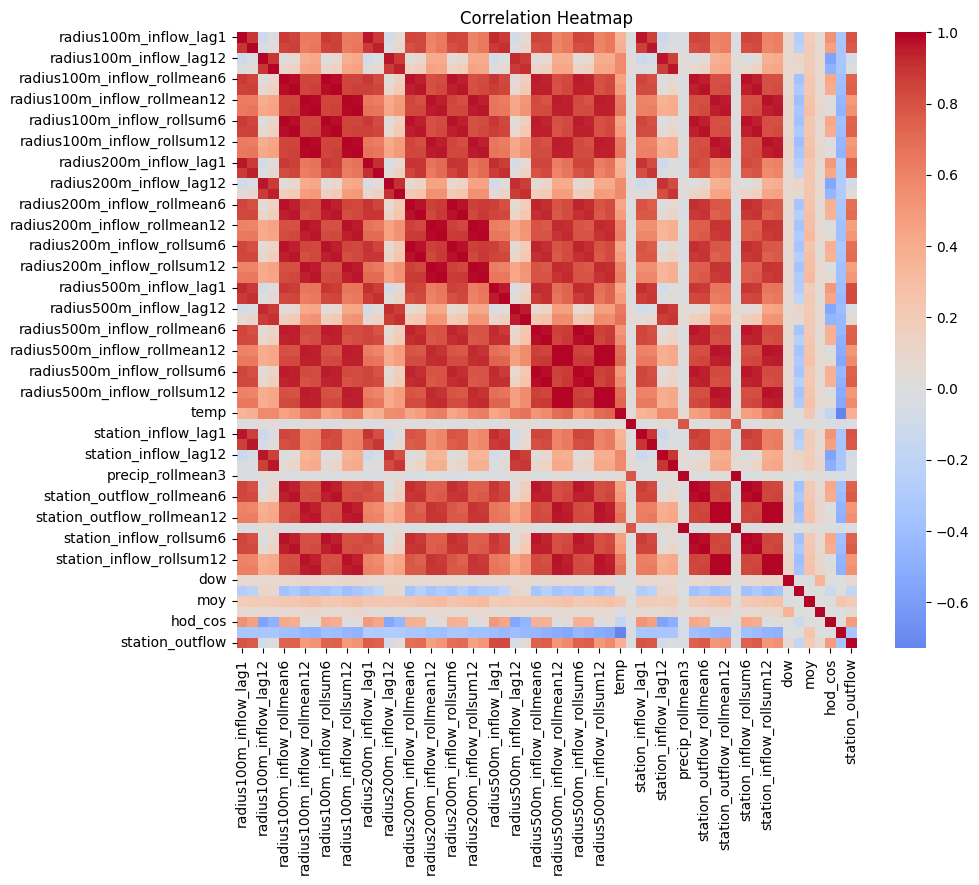

In [38]:
pdf = screen_df.select(NUMERIC_COLS + [TARGET_COL]).toPandas()
plt.figure(figsize=(10,8))
sns.heatmap(pdf.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

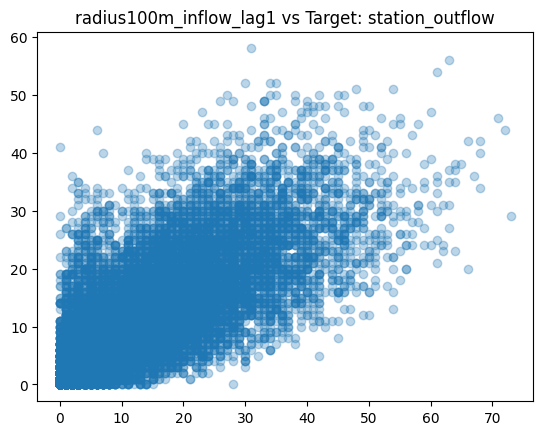

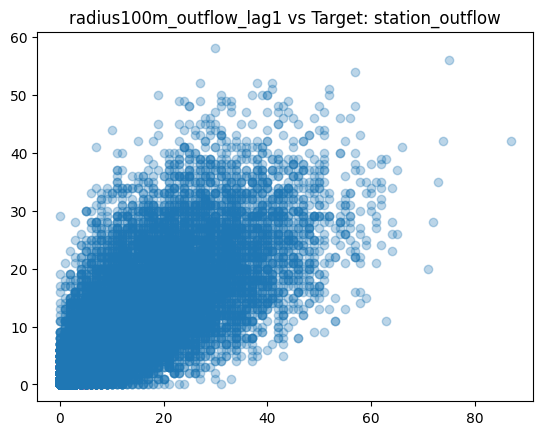

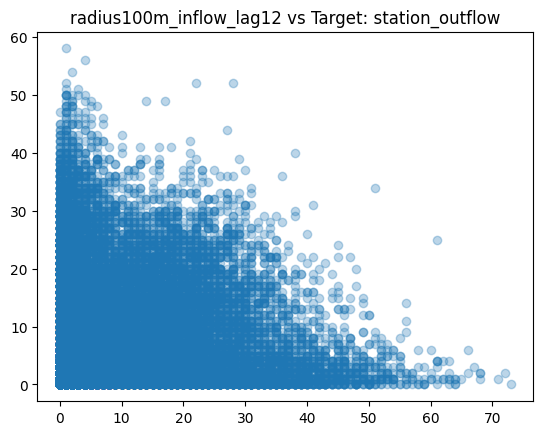

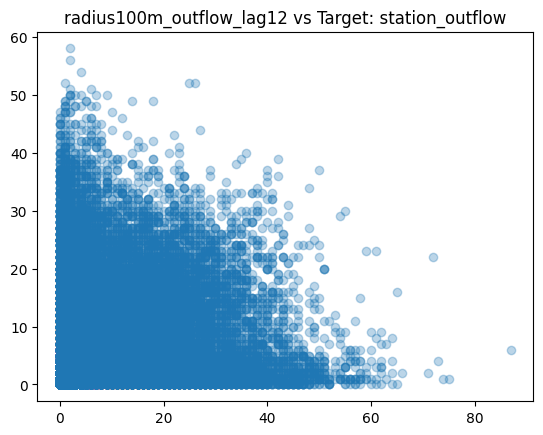

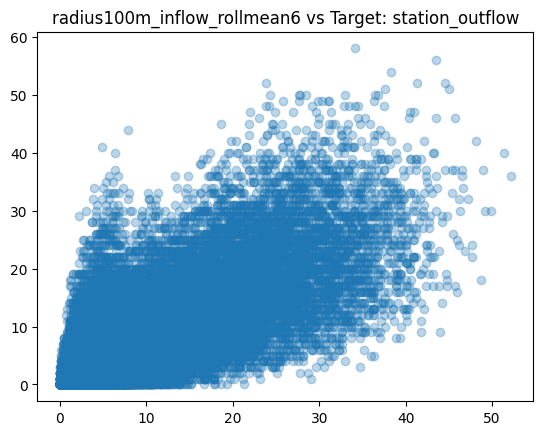

In [39]:
for col in NUMERIC_COLS[:5]:
    plt.scatter(pdf[col], pdf[TARGET_COL], alpha=0.3)
    plt.title(f"{col} vs Target: {TARGET_COL}")
    plt.show()

In [40]:
# exploratory tree-based importance
rf_screen = RandomForestRegressor(
    featuresCol="features_raw",
    labelCol=TARGET_COL,
    predictionCol="prediction",
    numTrees=80,
    maxDepth=8,
    seed=42
)
rf_screen_model = rf_screen.fit(screen_ready)

rf_importance_pdf = pd.DataFrame({
    "feature": screen_feature_names,
    "importance": list(rf_screen_model.featureImportances.toArray())
}).sort_values("importance", ascending=False)

rf_importance_pdf.head(20)

26/04/18 15:51:05 WARN DAGScheduler: Broadcasting large task binary with size 1190.5 KiB
26/04/18 15:51:08 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/04/18 15:51:13 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


,feature,importance
25,radius500m_outflow_lag1,0.358760
24,radius500m_inflow_lag1,0.148506
38,station_inflow_lag1,0.092663
13,radius200m_outflow_lag1,0.066017
0,radius100m_inflow_lag1,0.062868
53,hod,0.041683
44,station_outflow_rollmean6,0.026151
49,station_outflow_rollsum6,0.025637
56,hod_cos,0.024701
1,radius100m_outflow_lag1,0.019372


In [41]:
# exploratory linear importance using standardized features
lr_screen = LinearRegression(
    featuresCol="features_scaled",
    labelCol=TARGET_COL,
    predictionCol="prediction",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)
lr_screen_model = lr_screen.fit(screen_ready)

lr_importance_pdf = pd.DataFrame({
    "feature": screen_feature_names,
    "coefficient": list(lr_screen_model.coefficients.toArray())
})
lr_importance_pdf["abs_coefficient"] = lr_importance_pdf["coefficient"].abs()
lr_importance_pdf = lr_importance_pdf.sort_values("abs_coefficient", ascending=False)

lr_importance_pdf.head(20)

26/04/18 15:51:20 WARN Instrumentation: [9f13d262] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:51:21 WARN Instrumentation: [9f13d262] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


,feature,coefficient,abs_coefficient
49,station_outflow_rollsum6,4.928741,4.928741
44,station_outflow_rollmean6,4.922354,4.922354
30,radius500m_inflow_rollmean12,-3.984123,3.984123
34,radius500m_inflow_rollsum12,-3.920795,3.920795
25,radius500m_outflow_lag1,3.865921,3.865921
35,radius500m_outflow_rollsum12,3.841293,3.841293
31,radius500m_outflow_rollmean12,3.772044,3.772044
29,radius500m_outflow_rollmean6,-3.546131,3.546131
33,radius500m_outflow_rollsum6,-3.532705,3.532705
24,radius500m_inflow_lag1,3.330160,3.330160


In [42]:
# choose candidate features from the exploratory screen
TOP_N_TREE = 25
TOP_N_LINEAR = 25

tree_top = rf_importance_pdf.head(TOP_N_TREE)["feature"].tolist()
linear_top = lr_importance_pdf.head(TOP_N_LINEAR)["feature"].tolist()

screen_top_union = sorted(set(tree_top) | set(linear_top))
print("Union of shortlisted features:", len(screen_top_union))
screen_top_union[:20]

Union of shortlisted features: 31


['dow_cos',
 'hod',
 'hod_cos',
 'radius100m_inflow_lag1',
 'radius100m_outflow_lag1',
 'radius100m_outflow_rollsum6',
 'radius200m_inflow_lag1',
 'radius200m_outflow_lag1',
 'radius500m_inflow_lag1',
 'radius500m_inflow_lag12',
 'radius500m_inflow_rollmean12',
 'radius500m_inflow_rollmean6',
 'radius500m_inflow_rollsum12',
 'radius500m_inflow_rollsum6',
 'radius500m_outflow_lag1',
 'radius500m_outflow_lag12',
 'radius500m_outflow_rollmean12',
 'radius500m_outflow_rollmean6',
 'radius500m_outflow_rollsum12',
 'radius500m_outflow_rollsum6']

In [43]:
## set USE_SCREENED_FEATURES to True if want to use reduced feature set
USE_SCREENED_FEATURES = False

if USE_SCREENED_FEATURES:
    # screen_top_union contains expanded names after OHE, so for actual assembly we keep all original columns
    # and later inspect importance again on the training-only data
    print("Using original columns but screened results only as guidance.")

MODEL_NUMERIC_COLS = NUMERIC_COLS
MODEL_BOOLEAN_COLS = BOOLEAN_COLS
MODEL_CATEGORICAL_COLS = CATEGORICAL_COLS

fill_map = {c: 0.0 for c in MODEL_NUMERIC_COLS}
fill_map.update({c: 0 for c in MODEL_BOOLEAN_COLS})

train_df = train_df.fillna(fill_map)
val_df = val_df.fillna(fill_map)
test_df = test_df.fillna(fill_map)

indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in MODEL_CATEGORICAL_COLS]
encoders = [OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"]) for c in MODEL_CATEGORICAL_COLS]

feature_inputs = MODEL_NUMERIC_COLS + MODEL_BOOLEAN_COLS + [f"{c}_ohe" for c in MODEL_CATEGORICAL_COLS]
assembler = VectorAssembler(inputCols=feature_inputs, outputCol="features_raw", handleInvalid="keep")
scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withMean=False, withStd=True)

prep_pipe = Pipeline(stages=indexers + encoders + [assembler, scaler])
prep_model = prep_pipe.fit(train_df)

train_ready = prep_model.transform(train_df)
val_ready = prep_model.transform(val_df)
test_ready = prep_model.transform(test_df)

model_feature_names = get_feature_names_from_pipeline_model(prep_model, MODEL_NUMERIC_COLS, MODEL_BOOLEAN_COLS, MODEL_CATEGORICAL_COLS)
print("Prepared feature count:", len(model_feature_names))

Prepared feature count: 68


In [44]:
evaluator_specs = ["rmse", "mae", "r2"]

def evaluate_predictions(pred_df, label_col=TARGET_COL):
    out = {}
    for metric in evaluator_specs:
        ev = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName=metric)
        out[metric] = ev.evaluate(pred_df)
    return out

def fit_and_evaluate(model_name, estimator, train_data, eval_data, features_col):
    fitted = estimator.fit(train_data)
    pred = fitted.transform(eval_data)
    metrics = evaluate_predictions(pred, TARGET_COL)
    return {
        "model_name": model_name,
        "features_col": features_col,
        "fitted_model": fitted,
        "predictions": pred,
        "rmse": metrics["rmse"],
        "mae": metrics["mae"],
        "r2": metrics["r2"],
    }

def extract_tree_importance(model, feature_names):
    if hasattr(model, "featureImportances"):
        return pd.DataFrame({
            "feature": feature_names,
            "importance": list(model.featureImportances.toArray())
        }).sort_values("importance", ascending=False)
    return None

def extract_linear_importance(model, feature_names):
    if hasattr(model, "coefficients"):
        pdf = pd.DataFrame({
            "feature": feature_names,
            "coefficient": list(model.coefficients.toArray())
        })
        pdf["abs_coefficient"] = pdf["coefficient"].abs()
        return pdf.sort_values("abs_coefficient", ascending=False)
    return None

#### 11. First-round baseline training

Design choice:
- tree models use `features_raw`
- linear models use `features_scaled`
- Poisson GLR assumes a non-negative target, so use it mainly for `station_inflow` or `station_outflow`

Model Training - To Try All types of Time Series Regression supported by Spark

In [45]:
baseline_models = {
    "GBTRegressor": GBTRegressor(
        featuresCol="features_raw",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxIter=100,
        maxDepth=5,
        maxBins=32,
        stepSize=0.1,
        subsamplingRate=1.0,
        seed=42
    ),
    "RandomForestRegressor": RandomForestRegressor(
        featuresCol="features_raw",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        numTrees=100,
        maxDepth=8,
        maxBins=32,
        seed=42
    ),
    "DecisionTreeRegressor": DecisionTreeRegressor(
        featuresCol="features_raw",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxDepth=8,
        maxBins=32,
        seed=42
    ),
    "LinearRegression": LinearRegression(
        featuresCol="features_scaled",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxIter=100,
        regParam=0.1,
        elasticNetParam=0.0
    ),
    "GeneralizedLinearRegression": GeneralizedLinearRegression(
        featuresCol="features_scaled",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        family="poisson",
        link="log",
        maxIter=50,
        regParam=0.0
    )
}

In [46]:
baseline_results = []

for model_name, estimator in baseline_models.items():
    if model_name == "GeneralizedLinearRegression" and TARGET_COL == "station_netflow":
        print(f"Skipping {model_name} because Poisson GLR is not suitable for negative netflow targets.")
        continue

    features_col = estimator.getFeaturesCol()
    result = fit_and_evaluate(model_name, estimator, train_ready, val_ready, features_col)
    baseline_results.append(result)
    print(model_name, {k: result[k] for k in ['rmse', 'mae', 'r2']})

baseline_metrics_pdf = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["fitted_model", "predictions"]}
    for r in baseline_results
]).sort_values("rmse")

baseline_metrics_pdf

GBTRegressor {'rmse': 3.5465120217237267, 'mae': 2.327346367481724, 'r2': 0.8346803233026905}


26/04/18 15:52:17 WARN DAGScheduler: Broadcasting large task binary with size 1450.1 KiB
26/04/18 15:52:20 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/04/18 15:52:23 WARN DAGScheduler: Broadcasting large task binary with size 4.9 MiB
26/04/18 15:52:27 WARN DAGScheduler: Broadcasting large task binary with size 1133.6 KiB


RandomForestRegressor {'rmse': 3.6487365274454295, 'mae': 2.478762229601418, 'r2': 0.825012638233673}


DecisionTreeRegressor {'rmse': 3.861404158993018, 'mae': 2.598707653466877, 'r2': 0.8040198008455788}
LinearRegression {'rmse': 4.049956068853542, 'mae': 2.7807846732286725, 'r2': 0.7844131339690649}


26/04/18 15:52:37 WARN Instrumentation: [6d43a971] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:52:37 WARN Instrumentation: [6d43a971] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:52:37 WARN Instrumentation: [6d43a971] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:52:38 WARN Instrumentation: [6d43a971] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:52:38 WARN Instrumentation: [6d43a971] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:52:38 WARN Instrumentation: [6d43a971] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:52:38 WARN Instrumentation: [6d43a971] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:52:39 WARN Instrumentation: [6d43a971] Cholesky solv

GeneralizedLinearRegression {'rmse': 4.6295440391777865, 'mae': 3.1533496975980735, 'r2': 0.7182926916138965}


,model_name,features_col,rmse,mae,r2
0,GBTRegressor,features_raw,3.546512,2.327346,0.834680
1,RandomForestRegressor,features_raw,3.648737,2.478762,0.825013
2,DecisionTreeRegressor,features_raw,3.861404,2.598708,0.804020
3,LinearRegression,features_scaled,4.049956,2.780785,0.784413
4,GeneralizedLinearRegression,features_scaled,4.629544,3.153350,0.718293


#### 12. Training-only feature importance after the baseline round


In [47]:
importance_tables = {}

for r in baseline_results:
    name = r["model_name"]
    model = r["fitted_model"]
    if name in {"GBTRegressor", "RandomForestRegressor", "DecisionTreeRegressor"}:
        importance_tables[name] = extract_tree_importance(model, model_feature_names)
    elif name in {"LinearRegression", "GeneralizedLinearRegression"}:
        importance_tables[name] = extract_linear_importance(model, model_feature_names)

list(importance_tables.keys())

['GBTRegressor',
 'RandomForestRegressor',
 'DecisionTreeRegressor',
 'LinearRegression',
 'GeneralizedLinearRegression']

In [48]:
"""inspect top 3 features from all regresssors' importance table"""

print(importance_tables['GBTRegressor'].head(3))
print(importance_tables['RandomForestRegressor'].head(3))
print(importance_tables['DecisionTreeRegressor'].head(3))
print(importance_tables['LinearRegression'].head(3))
print(importance_tables['GeneralizedLinearRegression'].head(3))

                      feature  importance
25    radius500m_outflow_lag1    0.255130
44  station_outflow_rollmean6    0.098259
24     radius500m_inflow_lag1    0.085943
                    feature  importance
25  radius500m_outflow_lag1    0.333815
24   radius500m_inflow_lag1    0.156400
38      station_inflow_lag1    0.090558
                    feature  importance
25  radius500m_outflow_lag1    0.644071
24   radius500m_inflow_lag1    0.132190
53                      hod    0.054043
                     feature  coefficient  abs_coefficient
25   radius500m_outflow_lag1     3.562459         3.562459
24    radius500m_inflow_lag1     2.887038         2.887038
49  station_outflow_rollsum6     2.633922         2.633922
                      feature  coefficient  abs_coefficient
49   station_outflow_rollsum6     0.430356         0.430356
44  station_outflow_rollmean6     0.427172         0.427172
25    radius500m_outflow_lag1     0.385176         0.385176


#### 13. Manual time-aware hyperparameter tuning

Tunes using:
- `train_df` for fitting
- `val_df` for model selection

Which respects chronological order.

In [49]:
param_grids = {
    "GBTRegressor": [
        {"maxIter": 50, "maxDepth": 4, "stepSize": 0.05, "maxBins": 32},
        {"maxIter": 100, "maxDepth": 5, "stepSize": 0.05, "maxBins": 32},
        {"maxIter": 100, "maxDepth": 6, "stepSize": 0.1, "maxBins": 32},
    ],
    "RandomForestRegressor": [
        {"numTrees": 80, "maxDepth": 6, "maxBins": 32},
        {"numTrees": 120, "maxDepth": 8, "maxBins": 32},
        {"numTrees": 150, "maxDepth": 10, "maxBins": 64},
    ],
    "DecisionTreeRegressor": [
        {"maxDepth": 5, "maxBins": 32},
        {"maxDepth": 8, "maxBins": 32},
        {"maxDepth": 10, "maxBins": 64},
    ],
    "LinearRegression": [
        {"maxIter": 100, "regParam": 0.0, "elasticNetParam": 0.0},
        {"maxIter": 100, "regParam": 0.1, "elasticNetParam": 0.0},
        {"maxIter": 100, "regParam": 0.1, "elasticNetParam": 0.5},
        {"maxIter": 150, "regParam": 0.2, "elasticNetParam": 1.0},
    ],
    "GeneralizedLinearRegression": [
        {"maxIter": 50, "regParam": 0.0},
        {"maxIter": 100, "regParam": 0.0},
        {"maxIter": 100, "regParam": 0.1},
    ],
}


def build_estimator(model_name, params):
    if model_name == "GBTRegressor":
        return GBTRegressor(
            featuresCol="features_raw", labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, subsamplingRate=1.0, **params
        )
    if model_name == "RandomForestRegressor":
        return RandomForestRegressor(
            featuresCol="features_raw", labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, **params
        )
    if model_name == "DecisionTreeRegressor":
        return DecisionTreeRegressor(
            featuresCol="features_raw", labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, **params
        )
    if model_name == "LinearRegression":
        return LinearRegression(
            featuresCol="features_scaled", labelCol=TARGET_COL, predictionCol="prediction",
            **params
        )
    if model_name == "GeneralizedLinearRegression":
        return GeneralizedLinearRegression(
            featuresCol="features_scaled", labelCol=TARGET_COL, predictionCol="prediction",
            family="poisson", link="log", **params
        )
    raise ValueError("Unknown model")

In [50]:
tuning_rows = []

for model_name, grid in param_grids.items():
    if model_name == "GeneralizedLinearRegression" and TARGET_COL == "station_netflow":
        continue

    print(f"\nTuning {model_name}")
    for params in grid:
        est = build_estimator(model_name, params)
        fitted = est.fit(train_ready)
        pred = fitted.transform(val_ready)
        metrics = evaluate_predictions(pred, TARGET_COL)

        row = {
            "model_name": model_name,
            "params_json": json.dumps(params, sort_keys=True),
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
        }
        tuning_rows.append(row)
        print(row)

tuning_pdf = pd.DataFrame(tuning_rows).sort_values(["model_name", "rmse"])
tuning_pdf


Tuning GBTRegressor


{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 4, "maxIter": 50, "stepSize": 0.05}', 'rmse': 3.7128211230555737, 'mae': 2.535567739793513, 'r2': 0.8188118765491759}


{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 5, "maxIter": 100, "stepSize": 0.05}', 'rmse': 3.528111805213721, 'mae': 2.3385872059875847, 'r2': 0.8363913152293722}


26/04/18 15:54:35 WARN DAGScheduler: Broadcasting large task binary with size 1000.6 KiB
26/04/18 15:54:35 WARN DAGScheduler: Broadcasting large task binary with size 1001.1 KiB
26/04/18 15:54:35 WARN DAGScheduler: Broadcasting large task binary with size 1002.1 KiB
26/04/18 15:54:35 WARN DAGScheduler: Broadcasting large task binary with size 1002.9 KiB
26/04/18 15:54:35 WARN DAGScheduler: Broadcasting large task binary with size 1005.1 KiB
26/04/18 15:54:35 WARN DAGScheduler: Broadcasting large task binary with size 1008.8 KiB
26/04/18 15:54:35 WARN DAGScheduler: Broadcasting large task binary with size 1010.9 KiB
26/04/18 15:54:35 WARN DAGScheduler: Broadcasting large task binary with size 1011.3 KiB
26/04/18 15:54:35 WARN DAGScheduler: Broadcasting large task binary with size 1012.4 KiB
26/04/18 15:54:35 WARN DAGScheduler: Broadcasting large task binary with size 1013.1 KiB
26/04/18 15:54:35 WARN DAGScheduler: Broadcasting large task binary with size 1015.5 KiB
26/04/18 15:54:35 WAR

{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 6, "maxIter": 100, "stepSize": 0.1}', 'rmse': 3.5533641336843287, 'mae': 2.332384039727167, 'r2': 0.8340408875747253}

Tuning RandomForestRegressor


...

{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 50, "regParam": 0.0}', 'rmse': 4.6295440391777865, 'mae': 3.1533496975980735, 'r2': 0.7182926916138965}


26/04/18 15:58:08 WARN Instrumentation: [9e39ca37] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:58:08 WARN Instrumentation: [9e39ca37] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:58:08 WARN Instrumentation: [9e39ca37] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:58:09 WARN Instrumentation: [9e39ca37] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:58:09 WARN Instrumentation: [9e39ca37] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:58:09 WARN Instrumentation: [9e39ca37] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 15:58:09 WARN Instrumentation: [9e39ca37] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 15:58:10 WARN Instrumentation: [9e39ca37] Cholesky solv

{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 100, "regParam": 0.0}', 'rmse': 4.598190152887064, 'mae': 3.1429912977721566, 'r2': 0.7220955322818372}


{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 100, "regParam": 0.1}', 'rmse': 4.5672353916647115, 'mae': 3.2252580647949, 'r2': 0.7258246128514365}


,model_name,params_json,rmse,mae,r2
7,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",3.861404,2.598708,0.804020
6,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 5}",4.282886,2.998686,0.758901
8,DecisionTreeRegressor,"{""maxBins"": 64, ""maxDepth"": 10}",4.288943,2.774069,0.758219
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",3.528112,2.338587,0.836391
2,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 6, ""maxIter"": 100,...",3.553364,2.332384,0.834041
0,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 4, ""maxIter"": 50, ...",3.712821,2.535568,0.818812
15,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.1}",4.567235,3.225258,0.725825
14,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.0}",4.598190,3.142991,0.722096
13,GeneralizedLinearRegression,"{""maxIter"": 50, ""regParam"": 0.0}",4.629544,3.153350,0.718293
9,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",4.028319,2.766246,0.786710


In [51]:
best_params_pdf = tuning_pdf.sort_values("rmse").groupby("model_name", as_index=False).first()
best_params_pdf

,model_name,params_json,rmse,mae,r2
0,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",3.861404,2.598708,0.804020
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",3.528112,2.338587,0.836391
2,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.1}",4.567235,3.225258,0.725825
3,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",4.028319,2.766246,0.786710
4,RandomForestRegressor,"{""maxBins"": 64, ""maxDepth"": 10, ""numTrees"": 150}",3.561015,2.382783,0.833325


#### 14. Retrain with best parameters on the full 80% training window, then evaluate on the untouched 20% test set

In [52]:
train_full_ready = prep_model.transform(train_full_df.fillna(fill_map))
test_ready = prep_model.transform(test_df.fillna(fill_map))

final_results_outflow = []

for _, row in best_params_pdf.iterrows():
    model_name = row["model_name"]
    params = json.loads(row["params_json"])
    final_est = build_estimator(model_name, params)
    final_model = final_est.fit(train_full_ready)
    final_pred = final_model.transform(test_ready)
    final_metrics = evaluate_predictions(final_pred, TARGET_COL)

    final_results_outflow.append({
        "model_name": model_name,
        "params_json": json.dumps(params, sort_keys=True),
        "rmse": final_metrics["rmse"],
        "mae": final_metrics["mae"],
        "r2": final_metrics["r2"],
        "fitted_model": final_model,
        "predictions": final_pred,
    })

final_metrics_pdf_outflow = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["fitted_model", "predictions"]}
    for r in final_results_outflow
]).sort_values("rmse")

final_metrics_pdf_outflow

26/04/18 16:00:13 WARN Instrumentation: [b6351e43] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:00:14 WARN Instrumentation: [b6351e43] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:00:27 WARN DAGScheduler: Broadcasting large task binary with size 1134.5 KiB
26/04/18 16:00:32 WARN DAGScheduler: Broadcasting large task binary with size 2047.0 KiB
26/04/18 16:00:39 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
26/04/18 16:00:50 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
26/04/18 16:01:03 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
26/04/18 16:01:14 WARN DAGScheduler: Broadcasting large task binary with size 4.7 MiB
26/04/18 16:01:22 WARN DAGScheduler: Broadcasting large task binary with size 4.8 MiB
26/04/18 16:01:34 WARN DAGScheduler: Broadcasting large task binary with size 4.6 MiB
26/04/18 16:01:49 WARN DAGScheduler:

,model_name,params_json,rmse,mae,r2
4,RandomForestRegressor,"{""maxBins"": 64, ""maxDepth"": 10, ""numTrees"": 150}",3.780597,2.587739,0.837943
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",3.837504,2.609476,0.833028
0,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",4.228418,2.851824,0.797278
3,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",4.468866,3.062297,0.773567
2,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.1}",5.020728,3.550334,0.714189


In [53]:
"""getting the feature importance from the final models"""
final_importance_tables = {}

for r in final_results:
    name = r["model_name"]
    model = r["fitted_model"]
    if name in {"GBTRegressor", "RandomForestRegressor", "DecisionTreeRegressor"}:
        final_importance_tables[name] = extract_tree_importance(model, model_feature_names)
    elif name in {"LinearRegression", "GeneralizedLinearRegression"}:
        final_importance_tables[name] = extract_linear_importance(model, model_feature_names)

for name, pdf in final_importance_tables.items():
    print("\n", name)
    display(pdf.head(15))


 DecisionTreeRegressor


,feature,importance
24,radius500m_inflow_lag1,0.733277
25,radius500m_outflow_lag1,0.076500
53,hod,0.043693
43,station_inflow_rollmean6,0.040917
56,hod_cos,0.031152
39,station_outflow_lag1,0.019391
45,station_inflow_rollmean12,0.016571
30,radius500m_inflow_rollmean12,0.010999
52,dow,0.003771
55,dow_cos,0.003635



 GBTRegressor


,feature,importance
24,radius500m_inflow_lag1,0.272377
43,station_inflow_rollmean6,0.103956
53,hod,0.094782
25,radius500m_outflow_lag1,0.061096
56,hod_cos,0.042276
39,station_outflow_lag1,0.036996
52,dow,0.036572
55,dow_cos,0.031141
45,station_inflow_rollmean12,0.029059
30,radius500m_inflow_rollmean12,0.023162



 GeneralizedLinearRegression


,feature,coefficient,abs_coefficient
56,hod_cos,0.464920,0.464920
48,station_inflow_rollsum6,0.386332,0.386332
43,station_inflow_rollmean6,0.382872,0.382872
25,radius500m_outflow_lag1,0.331750,0.331750
35,radius500m_outflow_rollsum12,0.258846,0.258846
26,radius500m_inflow_lag12,0.257202,0.257202
31,radius500m_outflow_rollmean12,0.244644,0.244644
28,radius500m_inflow_rollmean6,-0.229481,0.229481
30,radius500m_inflow_rollmean12,-0.228635,0.228635
32,radius500m_inflow_rollsum6,-0.226254,0.226254



 LinearRegression


,feature,coefficient,abs_coefficient
24,radius500m_inflow_lag1,3.368235,3.368235
48,station_inflow_rollsum6,2.786341,2.786341
43,station_inflow_rollmean6,2.783879,2.783879
25,radius500m_outflow_lag1,2.512290,2.512290
30,radius500m_inflow_rollmean12,-2.027825,2.027825
34,radius500m_inflow_rollsum12,-2.012197,2.012197
35,radius500m_outflow_rollsum12,1.401093,1.401093
31,radius500m_outflow_rollmean12,1.384074,1.384074
27,radius500m_outflow_lag12,-1.350139,1.350139
26,radius500m_inflow_lag12,1.343823,1.343823



 RandomForestRegressor


,feature,importance
24,radius500m_inflow_lag1,0.261734
25,radius500m_outflow_lag1,0.209963
38,station_inflow_lag1,0.080215
0,radius100m_inflow_lag1,0.052696
39,station_outflow_lag1,0.045782
53,hod,0.042640
1,radius100m_outflow_lag1,0.040108
56,hod_cos,0.036960
48,station_inflow_rollsum6,0.034172
43,station_inflow_rollmean6,0.028775


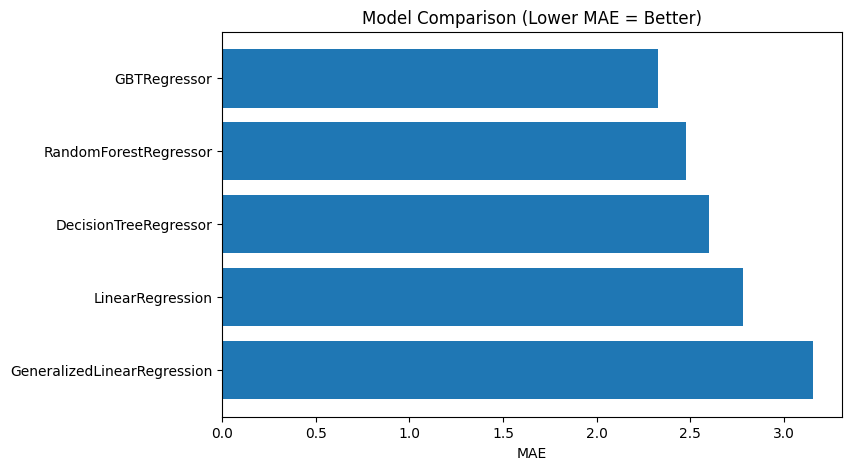

In [54]:
baseline_pdf = baseline_metrics_pdf.sort_values("mae")

plt.figure(figsize=(8,5))
plt.barh(baseline_pdf["model_name"], baseline_pdf["mae"])
plt.xlabel("MAE")
plt.title("Model Comparison (Lower MAE = Better)")
plt.gca().invert_yaxis()
plt.show()

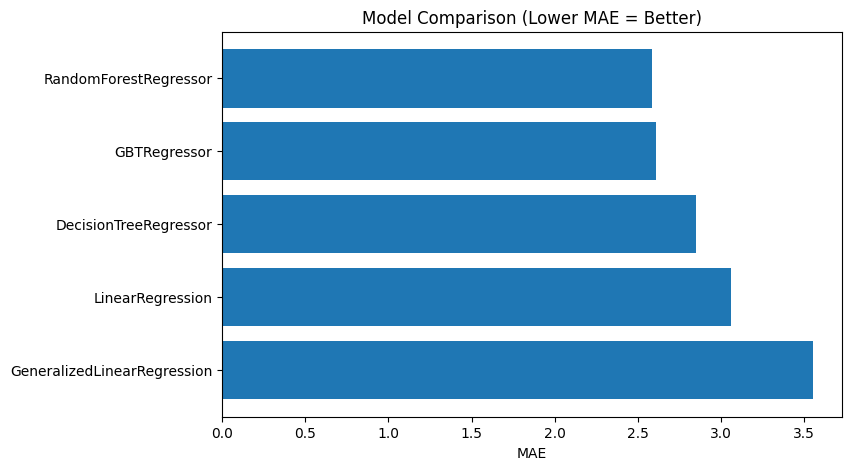

In [55]:
final_pdf = final_metrics_pdf_outflow.sort_values("mae")

plt.figure(figsize=(8,5))
plt.barh(final_pdf["model_name"], final_pdf["mae"])
plt.xlabel("MAE")
plt.title("Model Comparison (Lower MAE = Better)")
plt.gca().invert_yaxis()
plt.show()

##### 15. plot 

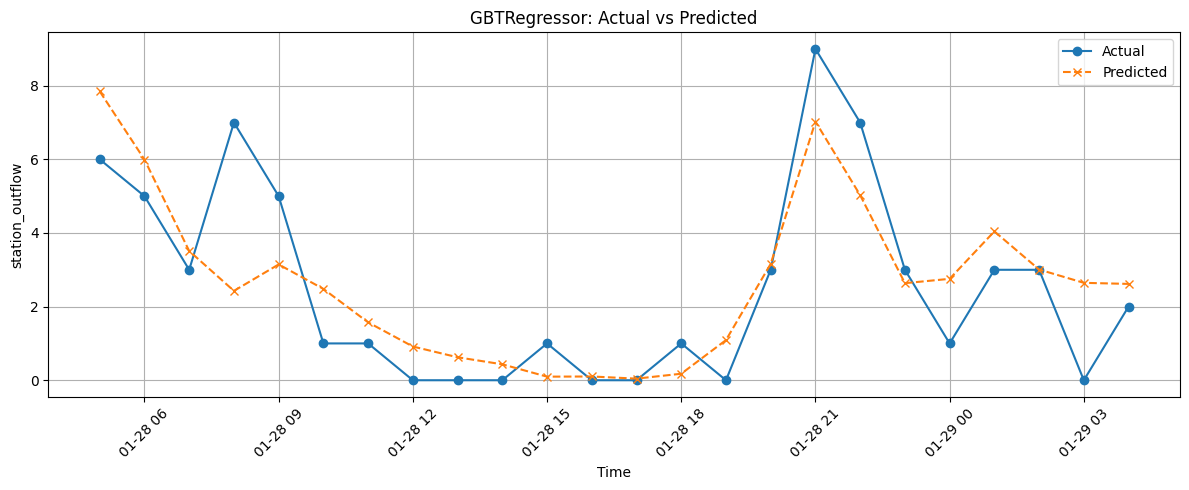

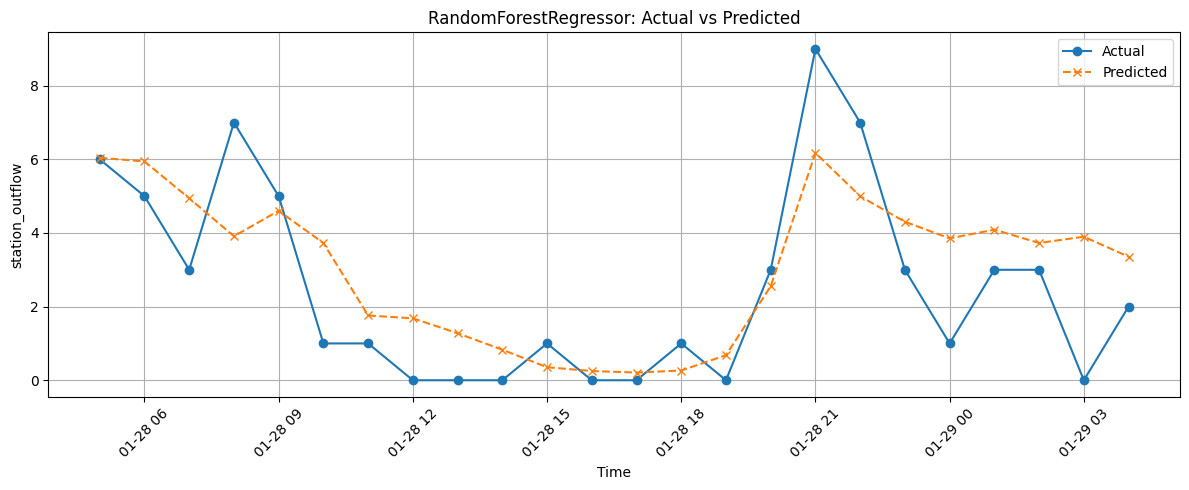

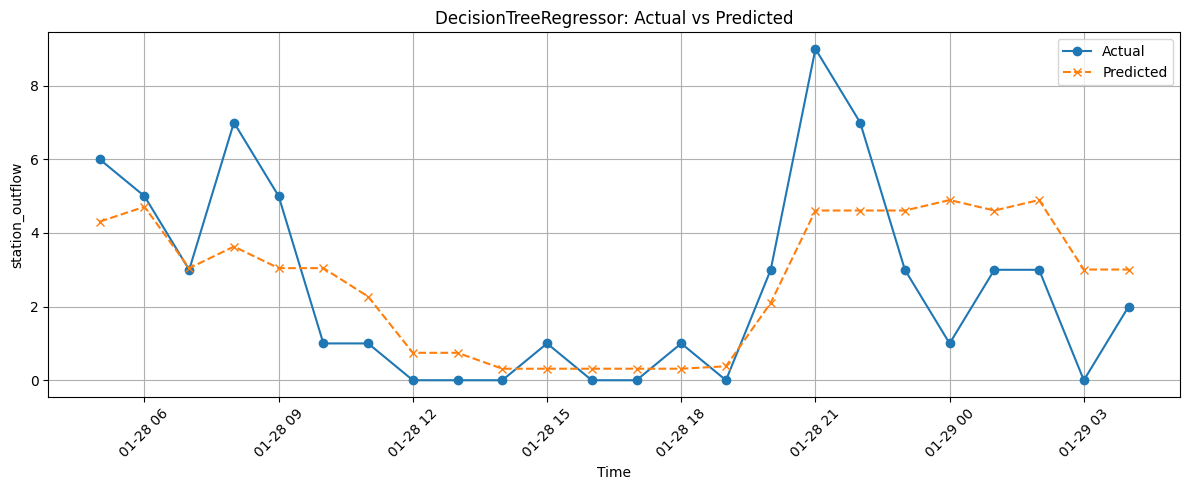

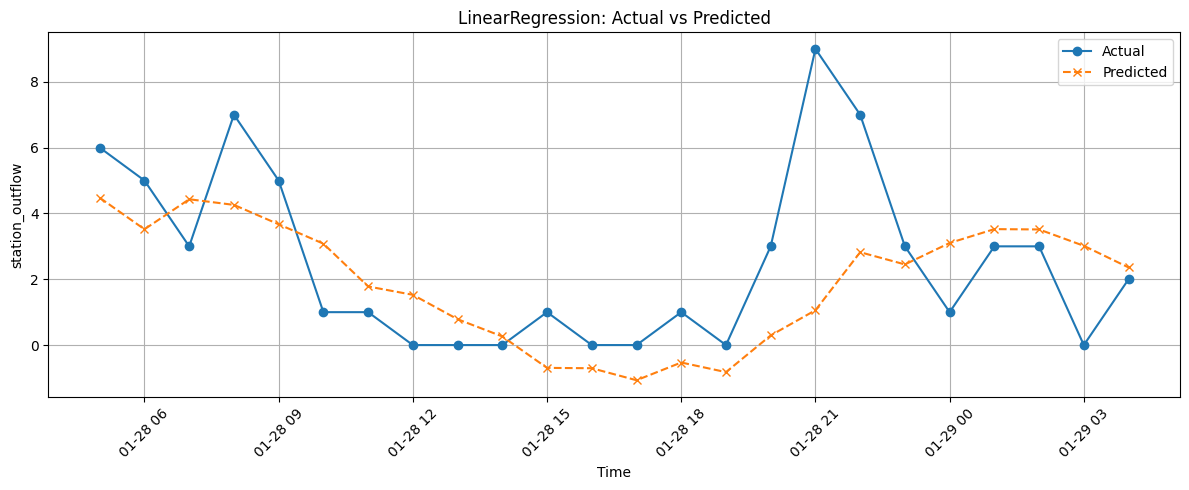

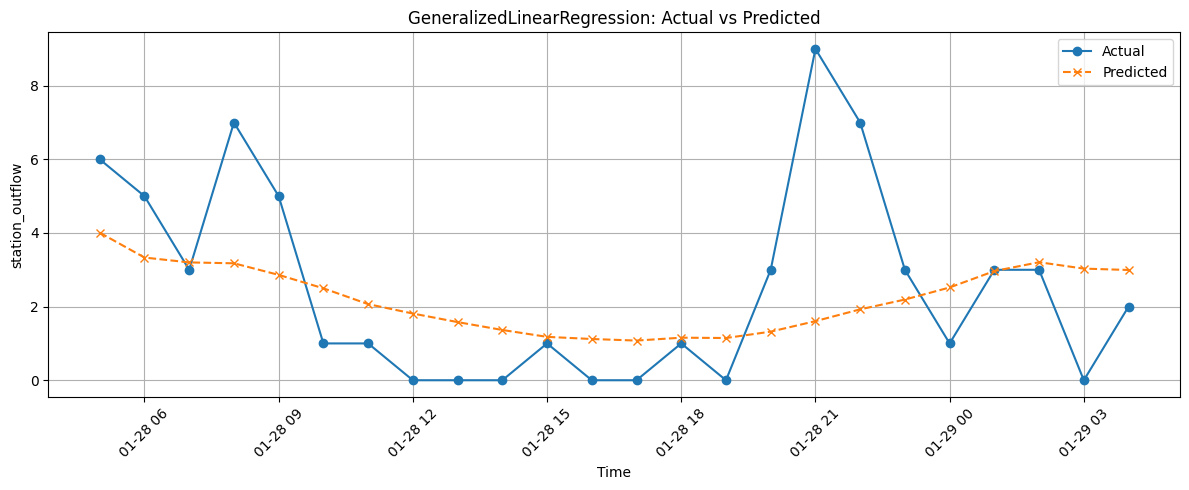

In [56]:
### plot baseline results 
for result in baseline_results:
    model_name = result["model_name"]
    pred_df = result["predictions"]

    plot_pdf = (
        pred_df
        .select("ts_hour", TARGET_COL, "prediction")
        .orderBy("ts_hour")
        .limit(24)
        .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(plot_pdf["ts_hour"], plot_pdf[TARGET_COL], label="Actual", marker="o")
    plt.plot(plot_pdf["ts_hour"], plot_pdf["prediction"], label="Predicted", linestyle="--", marker="x")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

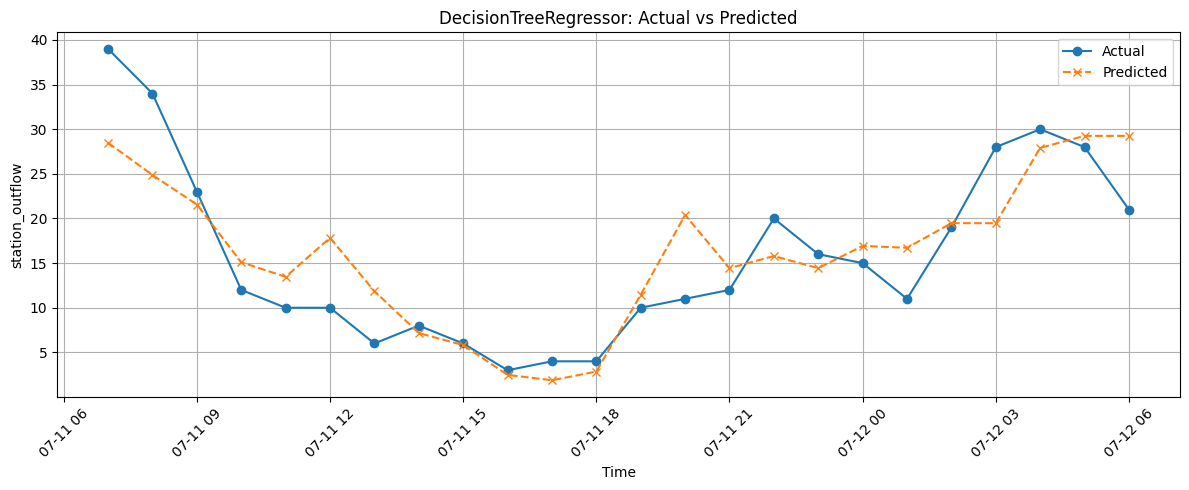

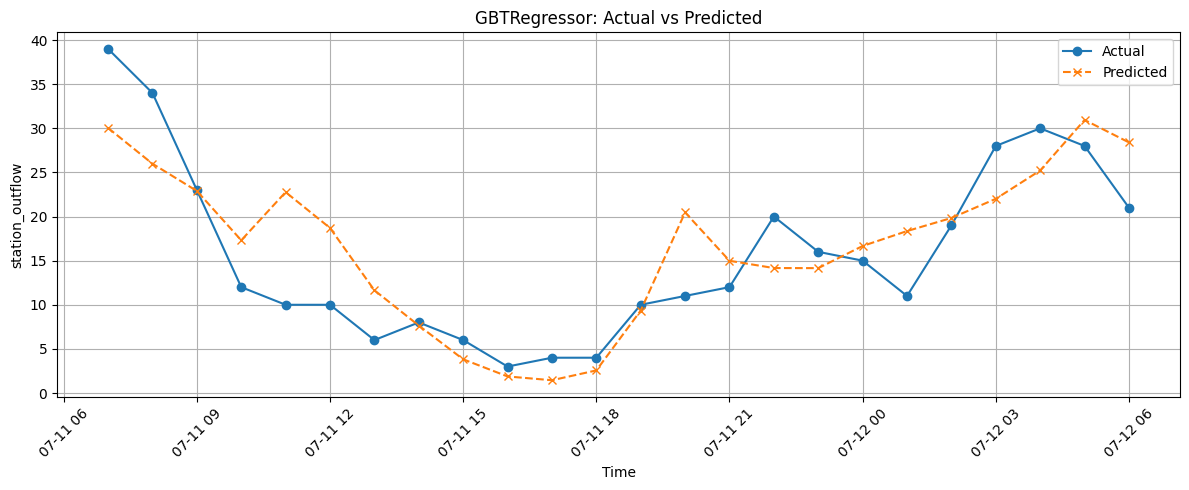

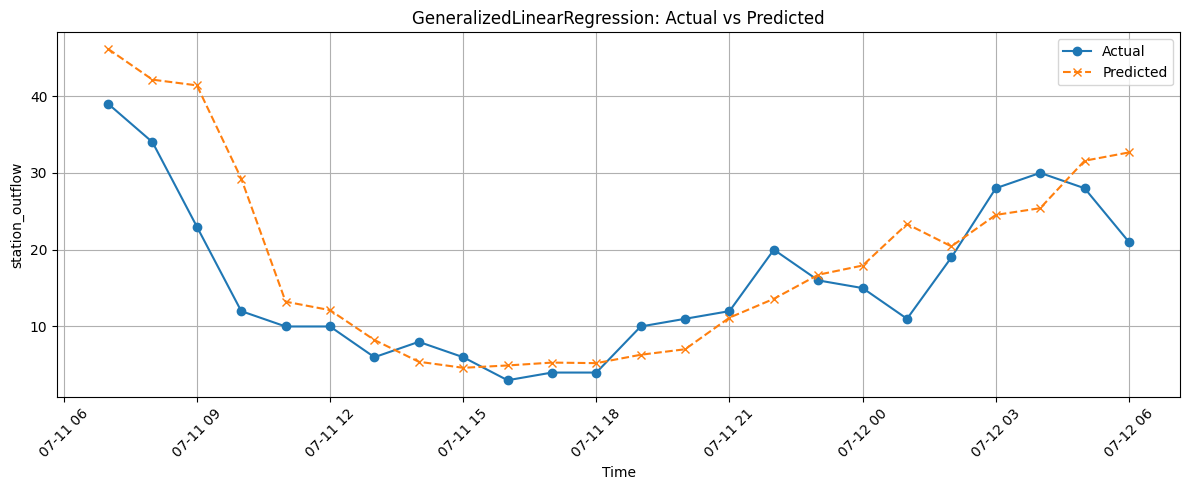

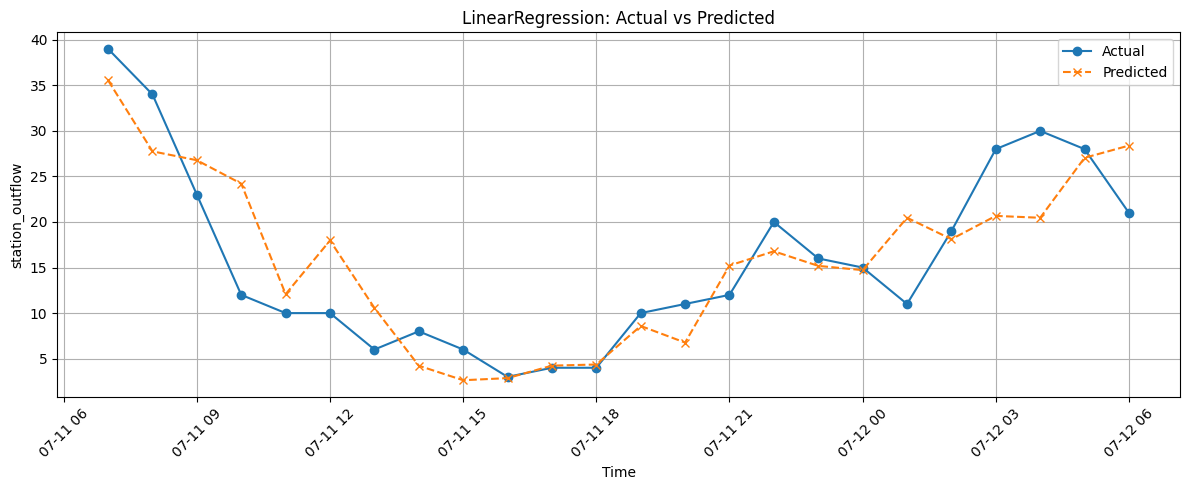

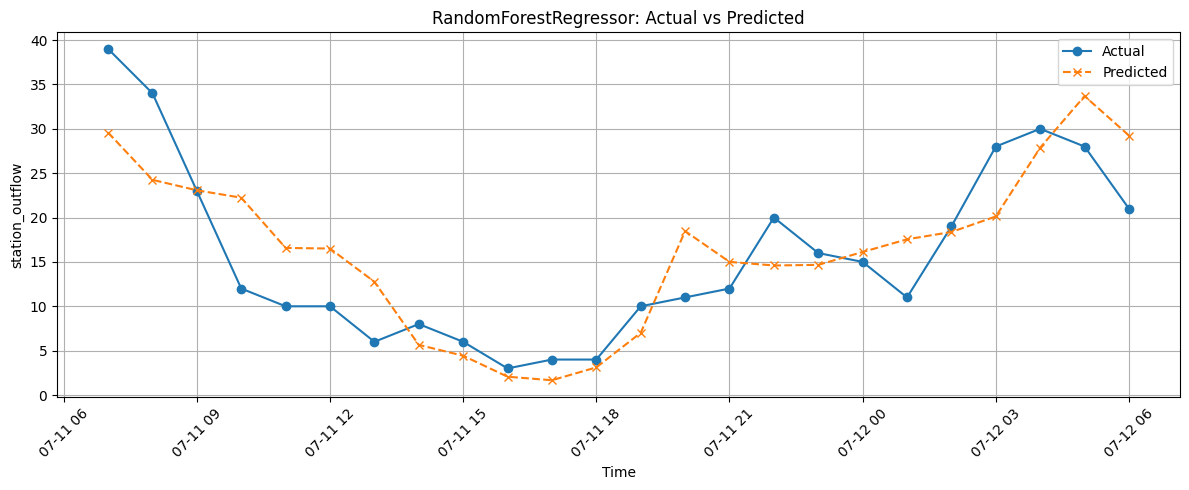

In [57]:
### plot final results 
for result in final_results_outflow:
    model_name = result["model_name"]
    pred_df = result["predictions"]

    plot_pdf = (
        pred_df
        .select("ts_hour", TARGET_COL, "prediction")
        .orderBy("ts_hour")
        .limit(24)
        .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(plot_pdf["ts_hour"], plot_pdf[TARGET_COL], label="Actual", marker="o")
    plt.plot(plot_pdf["ts_hour"], plot_pdf["prediction"], label="Predicted", linestyle="--", marker="x")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Saving the best trained OUTFLOW model

In [58]:
best_outflowModeling_result = min(final_results_outflow, key=lambda x: x["mae"])

best_outflow_model_name = best_outflowModeling_result["model_name"]
best_outflow_model = best_outflowModeling_result["fitted_model"]

print("Best model:", best_outflow_model_name)
print("MAE:", best_outflowModeling_result["mae"])
print("RMSE:", best_outflowModeling_result["rmse"])
print("R2:", best_outflowModeling_result["r2"])

Best model: RandomForestRegressor
MAE: 2.587739314658295
RMSE: 3.7805972575696747
R2: 0.8379433802278239


In [59]:
save_path = f"outputModels/best_outflow_model_{best_outflow_model_name}"
best_outflow_model.write().overwrite().save(save_path)
print(f"Model saved to: {save_path}")

26/04/18 16:02:46 WARN TaskSetManager: Stage 10547 contains a task of very large size (6001 KiB). The maximum recommended task size is 1000 KiB.


Model saved to: outputModels/best_outflow_model_RandomForestRegressor


## Netflow evaluation on post-2025-08-01 test window

Use the final best trained inflow model and final best trained outflow model on the explicit holdout window where `ts_hour >= 2025-08-01`, then compute:

`model_netflow = model_inflow - model_outflow`

Evaluate this against `station_netflow`, including the custom asymmetric loss from `yc__loss_func.py`.


In [63]:
from pyspark.ml.regression import RandomForestRegressionModel

best_inflow_model = RandomForestRegressionModel.load(
    "./outputModels/best_inflow_model_RandomForestRegressor"
)
best_outflow_model = RandomForestRegressionModel.load(
    "./outputModels/best_outflow_model_RandomForestRegressor"
)


In [64]:

# Build an explicit cutoff-based test input: all rows on/after 2025-08-01
cutoff_date = "2025-08-01"

cutoff_train_df = gold_0003_df.filter(F.col("ts_hour") < F.lit(cutoff_date))
cutoff_test_df = gold_0003_df.filter(F.col("ts_hour") >= F.lit(cutoff_date))

cutoff_fill_map = {c: 0.0 for c in MODEL_NUMERIC_COLS}
cutoff_fill_map.update({c: 0 for c in MODEL_BOOLEAN_COLS})

cutoff_train_df = cutoff_train_df.fillna(cutoff_fill_map)
cutoff_test_df = cutoff_test_df.fillna(cutoff_fill_map)

cutoff_indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in MODEL_CATEGORICAL_COLS
]
cutoff_encoders = [
    OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"])
    for c in MODEL_CATEGORICAL_COLS
]

cutoff_feature_inputs = (
    MODEL_NUMERIC_COLS
    + MODEL_BOOLEAN_COLS
    + [f"{c}_ohe" for c in MODEL_CATEGORICAL_COLS]
)

cutoff_assembler = VectorAssembler(
    inputCols=cutoff_feature_inputs,
    outputCol="features_raw",
    handleInvalid="keep"
)
cutoff_scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=False,
    withStd=True
)

cutoff_prep_pipe = Pipeline(stages=cutoff_indexers + cutoff_encoders + [cutoff_assembler, cutoff_scaler])
cutoff_prep_model = cutoff_prep_pipe.fit(cutoff_train_df)

cutoff_test_ready = cutoff_prep_model.transform(cutoff_test_df)

print(f"Cutoff date: {cutoff_date}")
print(f"Cutoff-train rows: {cutoff_train_df.count()}")
print(f"Cutoff-test rows: {cutoff_test_df.count()}")


Cutoff date: 2025-08-01
Cutoff-train rows: 20185
Cutoff-test rows: 4425


In [65]:
# Null-safe netflow evaluation block

from pyspark.sql import functions as F
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd

# Score the explicit post-2025-08-01 test input using the best trained inflow and outflow models
best_inflow_pred_cutoff = (
    best_inflow_model
    .transform(cutoff_test_ready)
    .select("ts_hour", F.col("prediction").alias("model_inflow"))
    .dropDuplicates(["ts_hour"])
)

best_outflow_pred_cutoff = (
    best_outflow_model
    .transform(cutoff_test_ready)
    .select("ts_hour", F.col("prediction").alias("model_outflow"))
    .dropDuplicates(["ts_hour"])
)

optional_dashboard_cols = [
    c for c in ["num_available_bikes", "num_available_docks"]
    if c in cutoff_test_df.columns
]

netflow_eval_df = (
    cutoff_test_df
    .select("ts_hour", "station_netflow", *optional_dashboard_cols)
    .join(best_inflow_pred_cutoff, on="ts_hour", how="inner")
    .join(best_outflow_pred_cutoff, on="ts_hour", how="inner")
    .withColumn("model_netflow", F.col("model_inflow") - F.col("model_outflow"))
)

# Debug null counts before evaluation
null_check_df = netflow_eval_df.select(
    F.count("*").alias("total_rows"),
    F.sum(F.col("station_netflow").isNull().cast("int")).alias("null_station_netflow"),
    F.sum(F.col("model_inflow").isNull().cast("int")).alias("null_model_inflow"),
    F.sum(F.col("model_outflow").isNull().cast("int")).alias("null_model_outflow"),
    F.sum(F.col("model_netflow").isNull().cast("int")).alias("null_model_netflow"),
)

null_check_df.show()

# Keep only complete rows for metric evaluation
netflow_eval_clean_df = (
    netflow_eval_df
    .filter(
        F.col("station_netflow").isNotNull() &
        F.col("model_inflow").isNotNull() &
        F.col("model_outflow").isNotNull() &
        F.col("model_netflow").isNotNull()
    )
    .withColumn(
        "asymmetric_loss_rmse_row",
        asymmetric_loss_col(
            y_true=F.col("station_netflow"),
            y_pred=F.col("model_netflow"),
            alpha=1.25,
            beta=1.0,
            loss_type="rmse",
        ),
    )
    .withColumn(
        "asymmetric_loss_mae_row",
        asymmetric_loss_col(
            y_true=F.col("station_netflow"),
            y_pred=F.col("model_netflow"),
            alpha=1.25,
            beta=1.0,
            loss_type="mae",
        ),
    )
)

# Optional: inspect dropped rows if needed
dropped_rows_df = netflow_eval_df.filter(
    F.col("station_netflow").isNull() |
    F.col("model_inflow").isNull() |
    F.col("model_outflow").isNull() |
    F.col("model_netflow").isNull()
)

print("Rows kept for evaluation:", netflow_eval_clean_df.count())
print("Rows dropped due to nulls:", dropped_rows_df.count())

netflow_metrics = {
    "rmse": RegressionEvaluator(
        labelCol="station_netflow",
        predictionCol="model_netflow",
        metricName="rmse"
    ).evaluate(netflow_eval_clean_df),
    "mae": RegressionEvaluator(
        labelCol="station_netflow",
        predictionCol="model_netflow",
        metricName="mae"
    ).evaluate(netflow_eval_clean_df),
    "r2": RegressionEvaluator(
        labelCol="station_netflow",
        predictionCol="model_netflow",
        metricName="r2"
    ).evaluate(netflow_eval_clean_df),
    "asymmetric_rmse_mean": asymmetric_loss_mean(
        netflow_eval_clean_df,
        y_true_col="station_netflow",
        y_pred_col="model_netflow",
        alpha=1.25,
        beta=1.0,
        loss_type="rmse",
    ),
    "asymmetric_mae_mean": asymmetric_loss_mean(
        netflow_eval_clean_df,
        y_true_col="station_netflow",
        y_pred_col="model_netflow",
        alpha=1.25,
        beta=1.0,
        loss_type="mae",
    ),
}

display(pd.DataFrame([netflow_metrics]))

output_cols = ["ts_hour", "station_netflow", "model_inflow", "model_outflow", "model_netflow"]
output_cols += optional_dashboard_cols

netflow_output_df = (
    netflow_eval_clean_df
    .select(*output_cols)
    .orderBy("ts_hour")
)

netflow_output_df.show(20, truncate=False)

+----------+--------------------+-----------------+------------------+------------------+
|total_rows|null_station_netflow|null_model_inflow|null_model_outflow|null_model_netflow|
+----------+--------------------+-----------------+------------------+------------------+
|      4425|                   0|                0|                 0|                 0|
+----------+--------------------+-----------------+------------------+------------------+

Rows kept for evaluation: 4425


Rows dropped due to nulls: 0


,rmse,mae,r2,asymmetric_rmse_mean,asymmetric_mae_mean
0,3.864463,2.557517,0.202625,16.899122,2.869767


+-------------------+---------------+------------------+------------------+--------------------+
|ts_hour            |station_netflow|model_inflow      |model_outflow     |model_netflow       |
+-------------------+---------------+------------------+------------------+--------------------+
|2025-08-01 00:00:00|-6             |14.698566040740298|15.852468045605386|-1.1539020048650883 |
|2025-08-01 01:00:00|3              |17.713164147727973|15.909879639911342|1.803284507816631   |
|2025-08-01 02:00:00|-10            |17.488265157097036|17.55346965568569 |-0.06520449858865263|
|2025-08-01 03:00:00|-8             |15.881543351501028|17.418171599723266|-1.5366282482222378 |
|2025-08-01 04:00:00|10             |25.058650997293448|22.651411408743645|2.4072395885498032  |
|2025-08-01 05:00:00|0              |32.680303772264324|35.62644160678006 |-2.9461378345157385 |
|2025-08-01 06:00:00|-4             |30.927188892752092|33.18189952186589 |-2.254710629113795  |
|2025-08-01 07:00:00|-8       

In [66]:
"""adding the canonical station id column for dashboard compatibility""" 
# all rows will have the same value since this is a single-station model
netflow_output_df = netflow_output_df.withColumn(
    "canonical_station_id",
    F.lit("STN_0003")
)
netflow_output_df = netflow_output_df.select(
    "canonical_station_id",
    "ts_hour",
    "station_netflow",
    "model_netflow"
)

In [67]:
print(netflow_output_df.show(20, truncate=False))
netflow_output_df.write.mode("overwrite").option("header", "true").csv("./outputNetflowEvaluation_STN0003/netflow_predictions.csv")

+--------------------+-------------------+---------------+--------------------+
|canonical_station_id|ts_hour            |station_netflow|model_netflow       |
+--------------------+-------------------+---------------+--------------------+
|STN_0003            |2025-08-01 00:00:00|-6             |-1.1539020048650883 |
|STN_0003            |2025-08-01 01:00:00|3              |1.803284507816631   |
|STN_0003            |2025-08-01 02:00:00|-10            |-0.06520449858865263|
|STN_0003            |2025-08-01 03:00:00|-8             |-1.5366282482222378 |
|STN_0003            |2025-08-01 04:00:00|10             |2.4072395885498032  |
|STN_0003            |2025-08-01 05:00:00|0              |-2.9461378345157385 |
|STN_0003            |2025-08-01 06:00:00|-4             |-2.254710629113795  |
|STN_0003            |2025-08-01 07:00:00|-8             |-2.180183511885822  |
|STN_0003            |2025-08-01 08:00:00|-3             |-1.530910116225428  |
|STN_0003            |2025-08-01 09:00:0

### station prediction VS actual plots

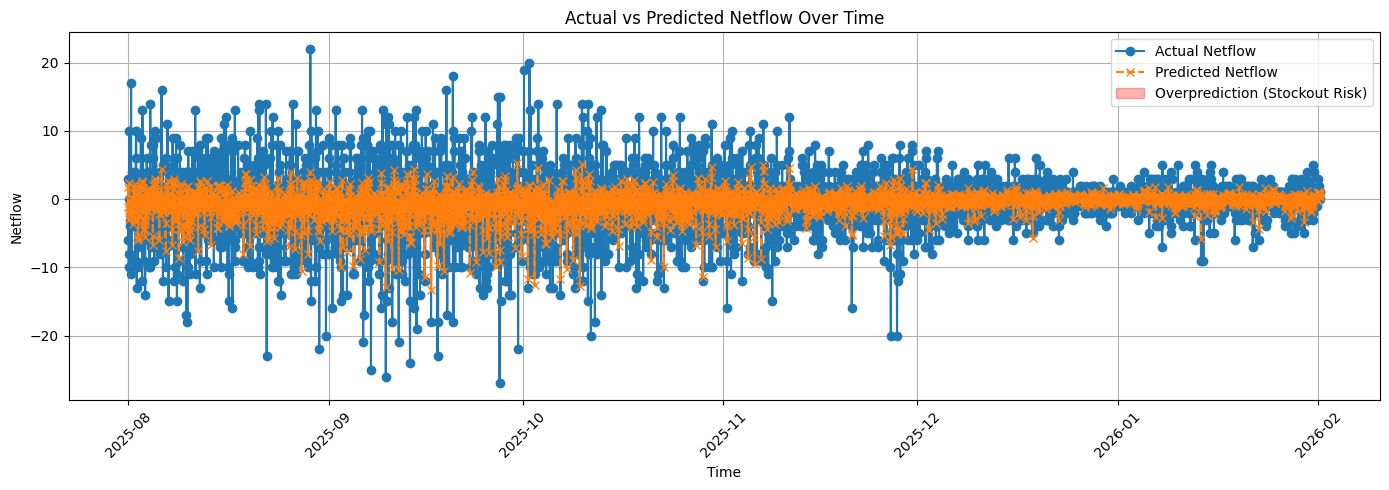

In [68]:
plot_pdf = (
    netflow_output_df
    .select("ts_hour", "station_netflow", "model_netflow")
    .orderBy("ts_hour")
    .toPandas()
)

plt.figure(figsize=(14, 5))

plt.plot(plot_pdf["ts_hour"], plot_pdf["station_netflow"], label="Actual Netflow", marker="o")
plt.plot(plot_pdf["ts_hour"], plot_pdf["model_netflow"], label="Predicted Netflow", linestyle="--", marker="x")

plt.title("Actual vs Predicted Netflow Over Time")
plt.xlabel("Time")
plt.ylabel("Netflow")
plt.fill_between(
    plot_pdf["ts_hour"],
    plot_pdf["station_netflow"],
    plot_pdf["model_netflow"],
    where=(plot_pdf["model_netflow"] > plot_pdf["station_netflow"]),
    color="red",
    alpha=0.3,
    label="Overprediction (Stockout Risk)"
)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



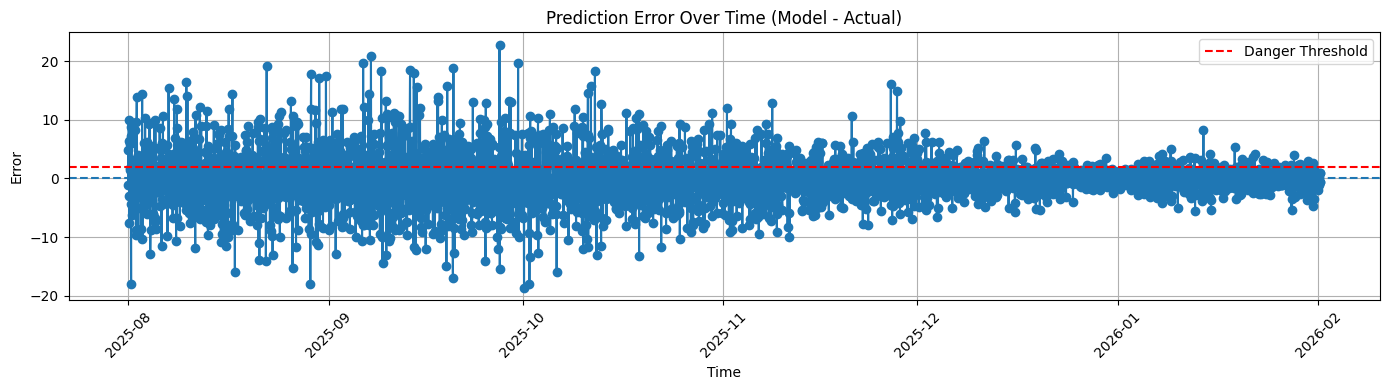

In [69]:
plot_pdf["error"] = plot_pdf["model_netflow"] - plot_pdf["station_netflow"]

plt.figure(figsize=(14, 4))

plt.plot(plot_pdf["ts_hour"], plot_pdf["error"], marker="o")

plt.axhline(0, linestyle="--")
plt.axhline(2, color="red", linestyle="--", label="Danger Threshold")

plt.title("Prediction Error Over Time (Model - Actual)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

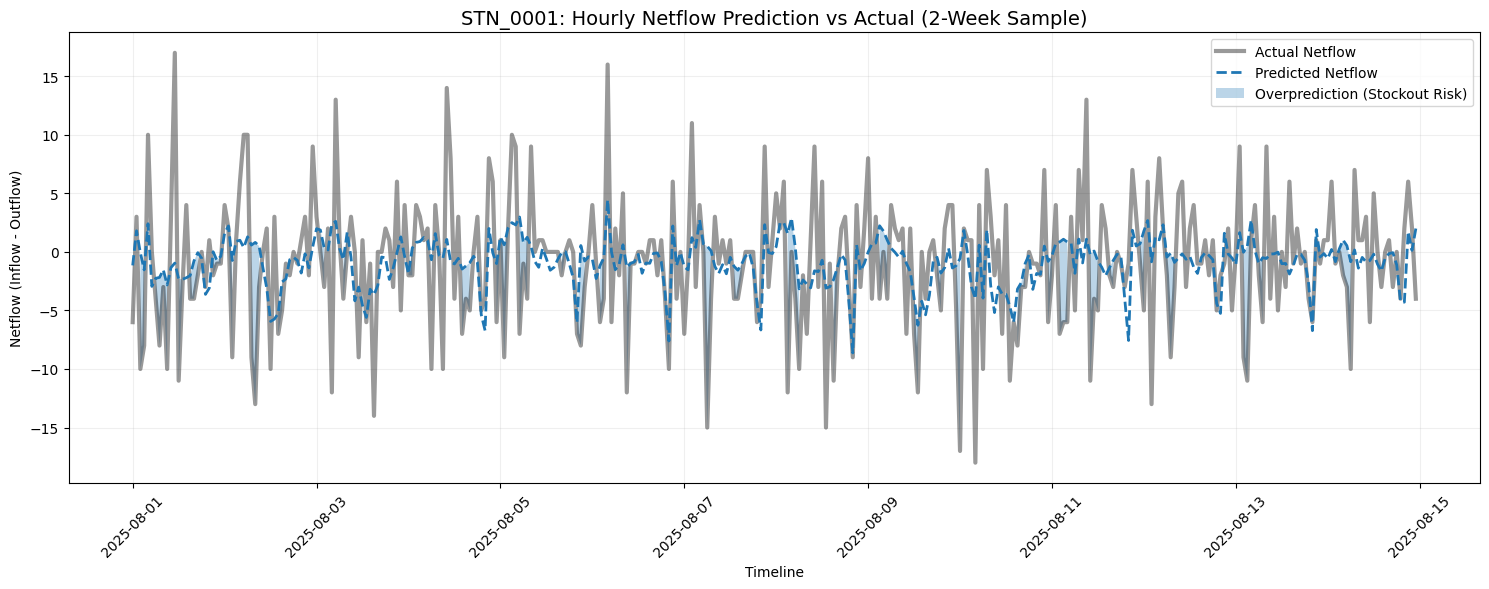

In [70]:
# 1. Extract 2 weeks (336 hours)
plot_pd = (
    netflow_output_df
    .orderBy("ts_hour")
    .limit(336)
    .select("ts_hour", "station_netflow", "model_netflow")
    .toPandas()
)

# 2. Plot
plt.figure(figsize=(15, 6))

plt.plot(
    plot_pd['ts_hour'],
    plot_pd['station_netflow'],
    label='Actual Netflow',
    color='black',
    alpha=0.4,
    linewidth=3
)

plt.plot(
    plot_pd['ts_hour'],
    plot_pd['model_netflow'],
    label='Predicted Netflow',
    linestyle='--',
    linewidth=2
)

plt.title("STN_0001: Hourly Netflow Prediction vs Actual (2-Week Sample)", fontsize=14)
plt.ylabel("Netflow (Inflow - Outflow)")
plt.xlabel("Timeline")
plt.fill_between(
    plot_pd["ts_hour"],
    plot_pd["station_netflow"],
    plot_pd["model_netflow"],
    where=(plot_pd["model_netflow"] > plot_pd["station_netflow"]),
    alpha=0.3,
    label="Overprediction (Stockout Risk)"
)
plt.legend()
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Visualising the loss 

Understanding
- how often did it overpredict?
- how much risky loss accumulated?

`Cumulative asymmetric loss` and `cumulative overprediction risk `better reflect business cost because overestimating netflow can lead to stockouts and lost rides. Since prior research indicates that the `cost of lost rides exceeds the cost of over-incentivizing riders`, these risk-weighted plots provide a more decision-relevant view of model performance.

`Standard absolute error` measures total forecast deviation.

In [71]:
from pyspark.sql.window import Window

# Running window by time
loss_window = Window.orderBy("ts_hour").rowsBetween(Window.unboundedPreceding, Window.currentRow)

# Build hourly and cumulative error/loss columns
cum_loss_sdf = (
    netflow_eval_clean_df
    .withColumn("abs_error", F.abs(F.col("station_netflow") - F.col("model_netflow")))
    .withColumn(
        "signed_error",
        F.col("model_netflow") - F.col("station_netflow")
    )
    .withColumn("cumulative_abs_error", F.sum("abs_error").over(loss_window))
    .withColumn("cumulative_asym_rmse_loss", F.sum("asymmetric_loss_rmse_row").over(loss_window))
    .withColumn("cumulative_asym_mae_loss", F.sum("asymmetric_loss_mae_row").over(loss_window))
    .select(
        "ts_hour",
        "abs_error",
        "signed_error",
        "asymmetric_loss_rmse_row",
        "asymmetric_loss_mae_row",
        "cumulative_abs_error",
        "cumulative_asym_rmse_loss",
        "cumulative_asym_mae_loss",
    )
)

cum_loss_pd = cum_loss_sdf.orderBy("ts_hour").toPandas()

26/04/18 16:09:32 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:09:32 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:09:32 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:09:32 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:09:33 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:09:33 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 1

#### Plot 1: cumulative absolute error + hourly absolute error

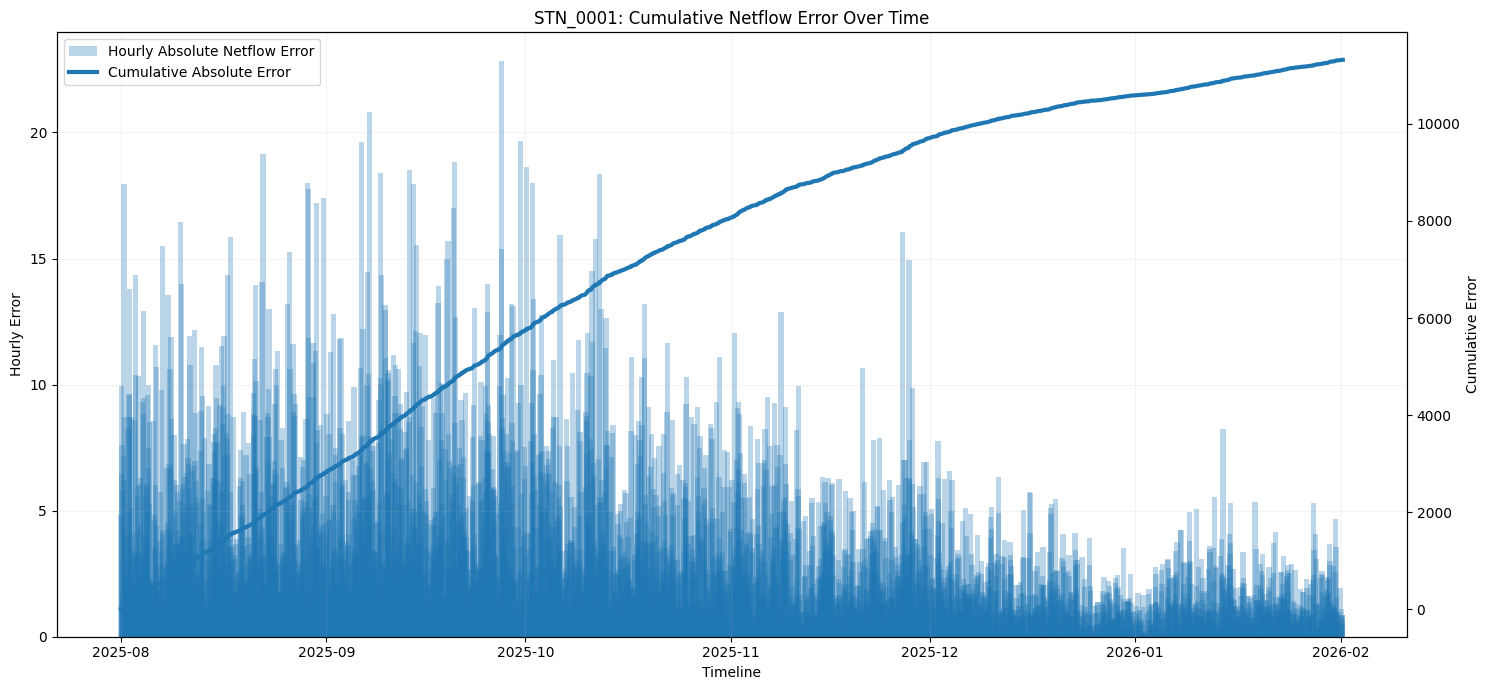

Total cumulative absolute netflow error: 11,317.01


In [72]:
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.bar(
    cum_loss_pd["ts_hour"],
    cum_loss_pd["abs_error"],
    alpha=0.3,
    label="Hourly Absolute Netflow Error"
)
ax1.set_ylabel("Hourly Error")

ax2 = ax1.twinx()
ax2.plot(
    cum_loss_pd["ts_hour"],
    cum_loss_pd["cumulative_abs_error"],
    linewidth=3,
    label="Cumulative Absolute Error"
)
ax2.set_ylabel("Cumulative Error")

plt.title("STN_0001: Cumulative Netflow Error Over Time")
ax1.set_xlabel("Timeline")
ax1.grid(True, alpha=0.15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

total_abs_error = cum_loss_pd["cumulative_abs_error"].iloc[-1]
print(f"Total cumulative absolute netflow error: {total_abs_error:,.2f}")

#### Plot 2: cumulative asymmetric loss

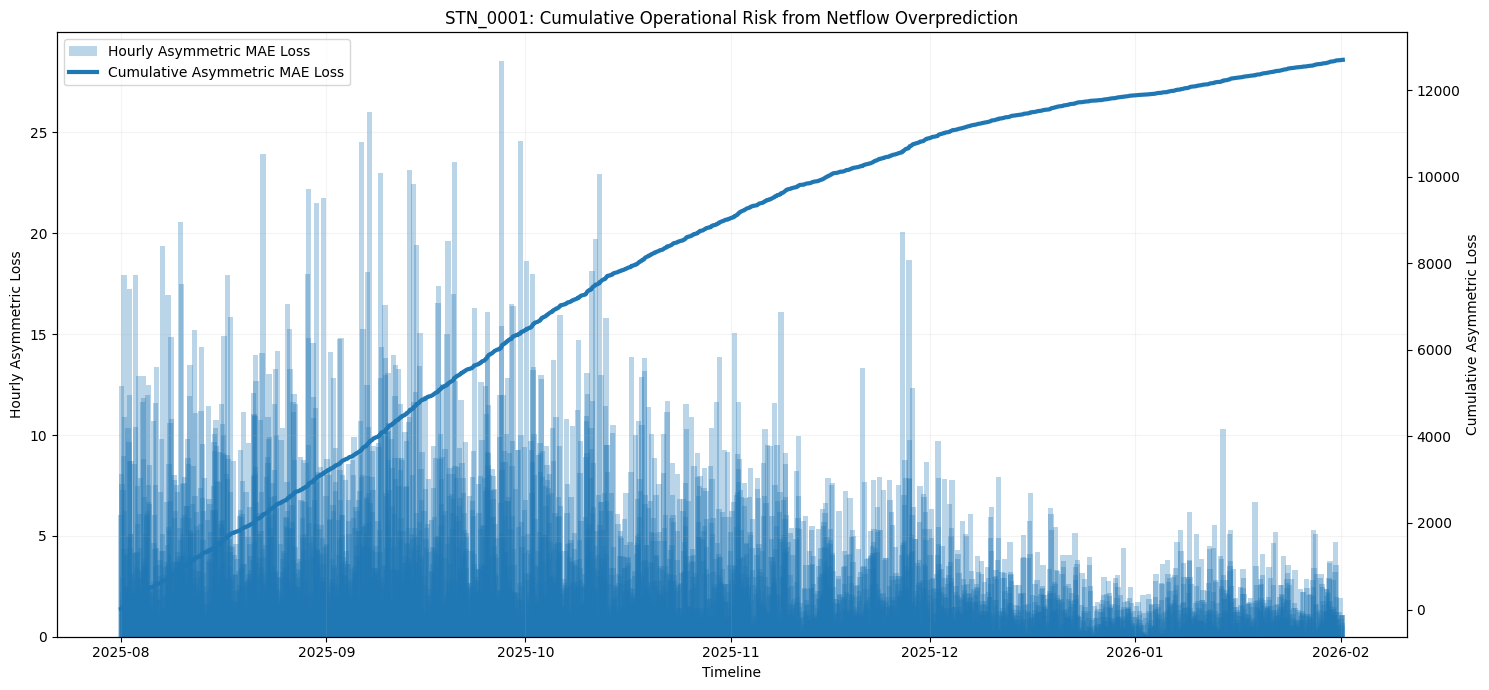

Total cumulative asymmetric MAE loss: 12,698.72


In [73]:
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.bar(
    cum_loss_pd["ts_hour"],
    cum_loss_pd["asymmetric_loss_mae_row"],
    alpha=0.3,
    label="Hourly Asymmetric MAE Loss"
)
ax1.set_ylabel("Hourly Asymmetric Loss")

ax2 = ax1.twinx()
ax2.plot(
    cum_loss_pd["ts_hour"],
    cum_loss_pd["cumulative_asym_mae_loss"],
    linewidth=3,
    label="Cumulative Asymmetric MAE Loss"
)
ax2.set_ylabel("Cumulative Asymmetric Loss")

plt.title("STN_0001: Cumulative Operational Risk from Netflow Overprediction")
ax1.set_xlabel("Timeline")
ax1.grid(True, alpha=0.15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

total_asym_mae = cum_loss_pd["cumulative_asym_mae_loss"].iloc[-1]
print(f"Total cumulative asymmetric MAE loss: {total_asym_mae:,.2f}")

#### Plot 3: cumulative risky overprediction only –> stockout???

26/04/18 16:10:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:10:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:10:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:10:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:10:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:10:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 1

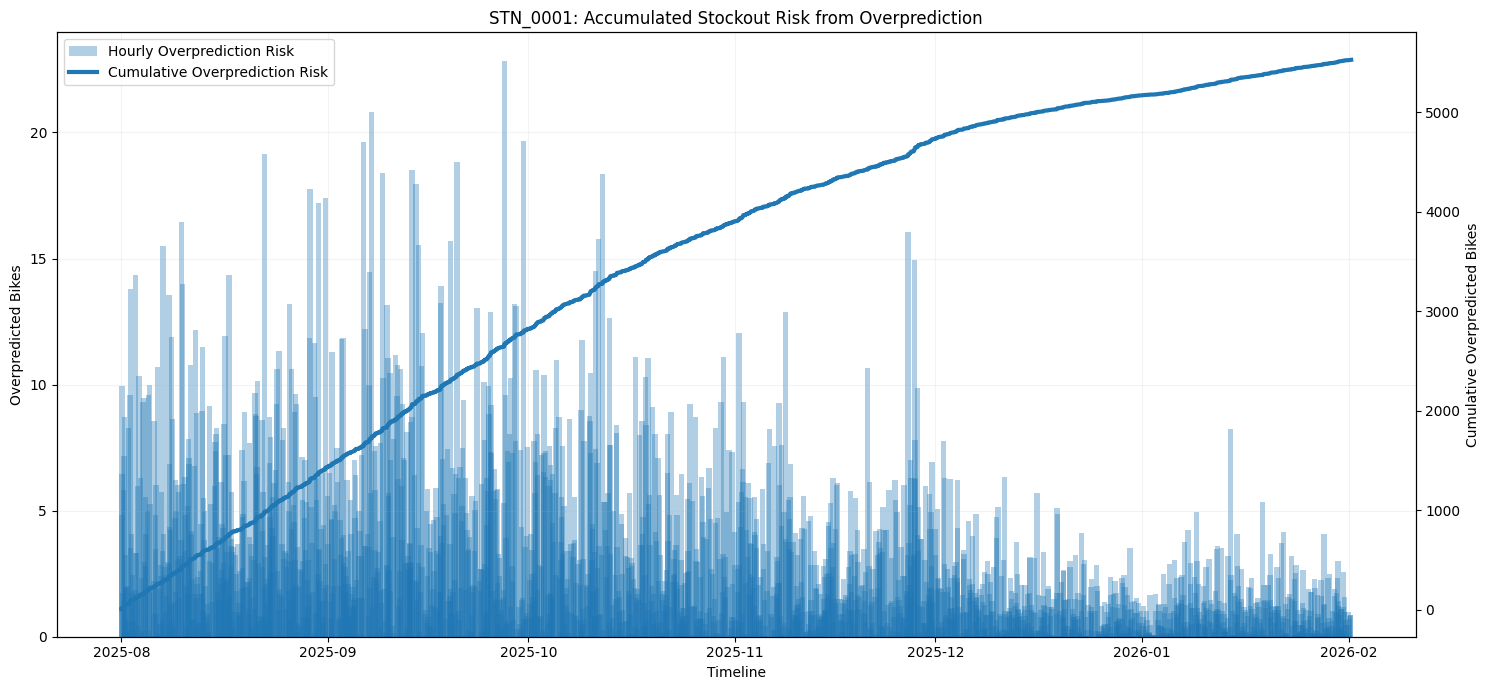

Total cumulative overprediction risk: 5,526.82 bikes


26/04/18 20:32:59 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 3666136 ms exceeds timeout 120000 ms
26/04/18 20:33:00 WARN SparkContext: Killing executors is not supported by current scheduler.
26/04/18 20:33:00 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1363)
	at 

In [74]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

risk_window = Window.orderBy("ts_hour").rowsBetween(Window.unboundedPreceding, Window.currentRow)

risk_sdf = (
    netflow_eval_clean_df
    .withColumn(
        "overprediction_amount",
        F.when(
            F.col("model_netflow") > F.col("station_netflow"),
            F.col("model_netflow") - F.col("station_netflow")
        ).otherwise(F.lit(0.0))
    )
    .withColumn(
        "cumulative_overprediction",
        F.sum("overprediction_amount").over(risk_window)
    )
    .select("ts_hour", "overprediction_amount", "cumulative_overprediction")
)

risk_pd = risk_sdf.orderBy("ts_hour").toPandas()

fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.bar(
    risk_pd["ts_hour"],
    risk_pd["overprediction_amount"],
    alpha=0.35,
    label="Hourly Overprediction Risk"
)
ax1.set_ylabel("Overpredicted Bikes")

ax2 = ax1.twinx()
ax2.plot(
    risk_pd["ts_hour"],
    risk_pd["cumulative_overprediction"],
    linewidth=3,
    label="Cumulative Overprediction Risk"
)
ax2.set_ylabel("Cumulative Overpredicted Bikes")

plt.title("STN_0001: Accumulated Stockout Risk from Overprediction")
ax1.set_xlabel("Timeline")
ax1.grid(True, alpha=0.15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

total_risk = risk_pd["cumulative_overprediction"].iloc[-1]
print(f"Total cumulative overprediction risk: {total_risk:,.2f} bikes")